# Asteroid orbit optimization with PyGMO - Custom Environment - Actual shape consideration
Copyright (c) 2010-2022, Delft University of Technology. All rights reserved. This file is part of the Tudat. Redistribution  and use in source and binary forms, with or without modification, are permitted exclusively under the terms of the Modified BSD license. You should have received a copy of the license with this file. If not, please or visit: http://tudat.tudelft.nl/LICENSE.

## Objectives
The aim of this tutorial is to illustrate the use of PyGMO to optimize an astrodynamics problem simulated with tudatpy. The problem describes the orbit design around a small body; the [Themis asteroid](https://en.wikipedia.org/wiki/25143_Themis). This example consists of three parts that build on each other to ultimately perform an orbit optimization. The three parts are built up as follows: Custom Environment (this page), [Design Space Exploration](aoo_design_space_exploration.ipynb), and [Optimization](aoo_optimization.ipynb).

**This part of the example is focussed on the creation of a custom environment, using manually defined rotation, ephemeris, gravity field, and shape settings**. A PyGMO compatible Problem class is also created for the next parts of the example. Using this problem class, a propagation is conducted to show a possible trajectory orbiting Themis.


### NOTE

It is assumed that the reader of this tutorial is already familiar with the content of [this basic PyGMO tutorial](https://docs.tudat.space/en/latest/_src_advanced_topics/optimization_pygmo.html). The full PyGMO documentation is available [on this website](https://esa.github.io/pygmo2/index.html). Be careful to read the
correct the documentation webpage (there is also a similar one for previous yet now outdated versions [here](https://esa.github.io/pygmo/index.html); as you can see, they can easily be confused).
PyGMO is the Python counterpart of [PAGMO](https://esa.github.io/pagmo2/index.html).

## Import statements
The required import statements are made here, at the very beginning.

Some standard modules are first loaded. These are `os`, `numpy` and `matplotlib.pyplot`.

Then, the different modules of `tudatpy` that will be used are imported.

Finally, in this example, we also need to import the `pygmo` library.

In [1]:
# Load standard modules
import os
import numpy as np
# Uncomment the following to make plots interactive
# %matplotlib widget
from matplotlib import pyplot as plt
from itertools import combinations as comb


# Load tudatpy modules
from tudatpy.data import save2txt
from tudatpy import constants
from tudatpy.interface import spice
from tudatpy.astro import element_conversion
from tudatpy.astro import frame_conversion
from tudatpy.dynamics import environment_setup
from tudatpy.dynamics import propagation_setup
from tudatpy.dynamics import simulator
from tudatpy.util import pareto_optimums

# Load pygmo library
import pygmo as pg

current_dir = os.path.abspath('')

## Creation of Custom Environment

Below a few helper functions are defined that create various custom environment models. These functions are used later in the example to create the simulation


### Themis rotation settings
The first helper function that is setup is `get_Themis_rotation_settings()`. This function can be called to get Themis rotation settings, of type [environment_setup.rotation_model.RotationModelSettings](https://py.api.tudat.space/en/latest/rotation_model.html#tudatpy.dynamics.environment_setup.rotation_model.RotationModelSettings), using a constant angular velocity.

This function only take the name of the body frame of Themis as an input.
In addition, some fixed parameters are defined in this function:

- The orientation of Themis pole, as:
    - The pole declination of -66.3 deg.
    - The pole right ascension 90.53 deg.
    - The meridian fixed at 0 deg.
- The rotation rate of Themis of 712.143 deg/Earth day.

In [2]:
def get_Themis_rotation_settings(Themis_body_frame_name):
    # Definition of initial Themis orientation conditions through the pole orientation
    pole_declination = np.deg2rad(59.8)     # Declination
    pole_right_ascension = np.deg2rad(125.6)  # Right ascension
    meridian_at_epoch = 0.0                   # Meridian

    # Define initial Themis orientation in inertial frame (equatorial plane)
    initial_orientation_j2000 = frame_conversion.inertial_to_body_fixed_rotation_matrix(
        pole_declination, pole_right_ascension, meridian_at_epoch)
    
    # Get initial Themis orientation in inertial frame but in the Ecliptic plane
    initial_orientation_eclipj2000 = np.matmul(spice.compute_rotation_matrix_between_frames(
        "J2000", "ECLIPJ2000", 0.0), initial_orientation_j2000)

    # Manually check the results, if desired
    check_results = False
    if check_results:
        np.set_printoptions(precision=100)
        print(initial_orientation_j2000)
    
        print(initial_orientation_eclipj2000)

    # Compute rotation rate
    # rotation_rate = np.deg2rad(712.143) / constants.JULIAN_DAY
    rotation_period = 8.374187 * 3600.0

    rotation_rate = 2.0 * np.pi / rotation_period

    # Set up rotational model for Themis with constant angular velocity
    return environment_setup.rotation_model.simple(
        "ECLIPJ2000", Themis_body_frame_name, initial_orientation_eclipj2000, 0.0, rotation_rate)

### Themis ephemeris settings
The next helper function defined, `get_Themis_ephemeris_settings()`, that can be used to set the ephemeris of Themis.

The ephemeris for Themis are set using a Keplerian orbit around the Sun. To do this, the initial position at a certain epoch is needed. This position is defined inside the function by the following kepler elements:

- Semi-major axis of $\approx$ 1.324 Astronomical Units ($\approx$ 1.98E+8 km).
- Eccentricity of $\approx$ 0.28.
- Inclination of $\approx$ 1.62 deg.
- Inclination of $\approx$ 1.62 deg.
- Argument of periapsis of $\approx$ 162.8 deg.
- Longitude of ascending node of $\approx$ 69.1 deg.
- Mean anomaly of $\approx$ 187.6 deg.

The only input that this function takes is the gravitational parameter of the Sun, which can be obtained using `spice.get_body_gravitational_parameter("Sun")`.

In [3]:
def get_Themis_ephemeris_settings(sun_gravitational_parameter):
    # Define Themis initial Kepler elements
    Themis_kepler_elements = np.array([
        3.1433 * constants.ASTRONOMICAL_UNIT,
        1.153499536381607E-01,
        np.deg2rad(7.366995500522935E-01),
        np.deg2rad(1.091193307580024E+02),
        np.deg2rad(3.639222711771391E+01),
        np.deg2rad(6.046711080424205E+01)])
    
    # Convert mean anomaly to true anomaly
    Themis_kepler_elements[5] = element_conversion.mean_to_true_anomaly(
        eccentricity=Themis_kepler_elements[1],
        mean_anomaly=Themis_kepler_elements[5])
    
    # Get epoch of initial Kepler elements (in Julian Days) 2025-Dec-12 00:00:00.0000
    kepler_elements_reference_julian_day = 2461021.5
    
    # Sets new reference epoch for Themis ephemerides (different from J2000)
    kepler_elements_reference_epoch = (kepler_elements_reference_julian_day - constants.JULIAN_DAY_ON_J2000) \
                                      * constants.JULIAN_DAY
    
    # Sets the ephemeris model
    return environment_setup.ephemeris.keplerian(
        Themis_kepler_elements,
        kepler_elements_reference_epoch,
        sun_gravitational_parameter,
        "Sun",
        "ECLIPJ2000")

### Themis gravity field settings
The `get_Themis_gravity_field_settings()` helper function can be used to get the gravity field settings of Themis.

It creates a Spherical Harmonics gravity field model expanded up to order 4 and degree 4. Normalized coefficients are hardcoded (see `normalized_cosine_coefficients` and `normalized_sine_coefficients`), as well as the gravitational parameter (2.36). The reference radius and the Themis body fixed frame are to be given as inputs to this function.

In [4]:
def get_Themis_gravity_field_settings(Themis_body_fixed_frame, Themis_radius):
    
    Themis_gravitational_parameter = 3.8e8  # m^3/s^2 — update if you have better value

    # 11x11 matrix → degrees 0-10, orders 0-10
    # Replace these with your actual data
    normalized_cosine_coefficients = np.array([
        [1.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=0
        [4.00437049323391e-10,      -2.00118621702933e-10,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=1
        [-0.0311484302600628, -0.00247282373836691,   -0.00274461339769334,  0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=2
        [-0.00200571383331492, -0.000432075164317321, 0.00194227892499834,0.00137270957639051, 0.0,    0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=3
        [0.00285332640564815,  0.00110182963502399, -0.000735718367676304, 0.000724745021813717, 0.00176998960899976, 0.0,   0.0,      0.0,      0.0,      0.0,      0.0],   # n=4
        [0.000830075337320937,      0.000287519798138761,      -0.000528107896235689,      -0.000867730821110781,      4.79023000648861e-05,      0.000879439295195050,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=5  ← your data
        [-0.000675558666706258,     -0.000205585971704600,      -0.000221135345635429,     -0.000318618655804238,      -0.000888434175048908,      -8.73422067817230e-05,     -0.000661361102590928,      0.0,      0.0,      0.0,      0.0],   # n=6
        [-0.000248341594690701,      -0.000163829109924533,      0.000232085380551457,      0.000258506065235110,      0.000160180230193337,      -0.000286377268939702,      6.77821275261500e-05,     0.000157407479968084,      0.0,      0.0,      0.0],   # n=7
        [0.000335217568650732,      -2.55140470111988e-05,      0.000274255269526383,      4.96324094064370e-05,      0.000342523466493208,     -1.86321450442635e-05,      0.000172675634502437,     9.50587862238274e-05,      0.000145987430976338,      0.0,      0.0],   # n=8
        [6.99720204690460e-05,      8.60097640010565e-05,      -0.000102732485716739,      -4.39268805337316e-05,      -0.000102645709362265,      0.000116936443373915,      -6.33826315277080e-05,      -5.20516633544555e-05,     -3.74472817959948e-05,      2.61212670888696e-05,      0.0],   # n=9
        [-0.000144111884090325,      2.32066521881085e-05,      -0.000126297847367392,      -2.62937726762541e-05,      -0.000124821278562081,      1.97212481561922e-05,      -4.97665457889904e-05,      -3.59202127991231e-05,      -7.28226920211166e-05,      1.23255404885492e-06,      -8.44844997134115e-05],   # n=10
    ])

    normalized_sine_coefficients = np.array([
        # m=0          m=1                        m=2                       m=3                       m=4                       m=5                       m=6                       m=7                       m=8                       m=9                       m=10
        [ 0.0,         0.0,                       0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=0
        [ 0.0,        -1.12918257515491e-09,       0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=1
        [ 0.0,         0.00107223359971325,       -0.00332663415194219,      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=2
        [ 0.0,        -0.00907886970678376,       -0.000235642226308041,    -0.00453797805800339,       0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=3
        [ 0.0,        -0.000236332856522398,       0.000679356889179597,     0.00103902654905862,      -0.00164525397614147,      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=4
        [ 0.0,         0.00311673748224299,       -0.000197902324683847,     0.000723574770295993,     7.12712231701076e-05,      0.000728705277735932,      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=5
        [ 0.0,         9.08985833204355e-05,      -7.81012920836034e-05,    -0.000382933168574949,     0.000417670991355626,     -0.000244616302121161,     -0.000272475519450808,     0.0,                      0.0,                      0.0,                      0.0         ],  # n=6
        [ 0.0,        -0.000726023965052120,      -0.000157289026194778,    -0.000151049434293496,    -1.31229025167918e-05,     -0.000180291881759017,      4.75861083370220e-05,     -0.000466425371326853,     0.0,                      0.0,                      0.0         ],  # n=7
        [ 0.0,        -4.66199482564515e-05,       4.07552978692181e-05,     0.000141144082038173,    -7.01025270851237e-05,      3.48820998708198e-05,      9.78492071833127e-05,      2.78823107064210e-05,     -0.000108013182515871,     0.0,                      0.0         ],  # n=8
        [ 0.0,         0.000177445235331498,       0.000124031343956387,     0.000102169331575207,     3.03402767376233e-05,      0.000131791270134196,      1.21961070494812e-05,      0.000178265283377157,      3.51673248637755e-05,      4.88474288152410e-05,     0.0         ],  # n=9
        [ 0.0,         7.90100853753287e-06,      -1.42280089749264e-05,    -7.29562295080795e-05,     2.77916592967652e-06,     -2.60570209403151e-05,     -2.33055610543032e-05,     -2.66308045112190e-05,      2.55117509946166e-05,     -3.32601179349906e-05,    -3.94450492257997e-06],  # n=10
    ])
    # ← UNCOMMENT this and remove the central() call below
    return environment_setup.gravity_field.spherical_harmonic(
        gravitational_parameter=Themis_gravitational_parameter,
        reference_radius=Themis_radius,
        normalized_cosine_coefficients=normalized_cosine_coefficients,
        normalized_sine_coefficients=normalized_sine_coefficients,
        associated_reference_frame=Themis_body_fixed_frame)

    # ← REMOVE this line (was placeholder, ignores all SH structure)
    # return environment_setup.gravity_field.central(
    #     gravitational_parameter=Themis_gravitational_parameter)

### Themis shape settings
The next helper function defined, `get_Themis_shape_settings()` return the shape settings object for Themis. It uses a simple spherical model, and take the radius of Themis as input.

In [5]:
def get_Themis_shape_settings(vertices, faces):
    """
    Polyhedral shape model.
    vertices : (N, 3) float64 array — Cartesian coordinates in metres
    faces    : (M, 3) int32 array  — 0-based vertex indices, CCW from outside
    """
    # ── Type enforcement — Tudat is strict about these dtypes ────────────────
    vertices_f64 = np.asarray(vertices, dtype=np.float64)   # must be float64
    faces_i32    = np.asarray(faces,    dtype=np.int32)      # must be int32 ← key fix

    # ── Winding order check — normals must point outward ─────────────────────
    centroid = vertices_f64.mean(axis=0)
    n_inward = 0
    for f in faces_i32[:10]:                      # spot-check first 10 faces
        v0, v1, v2 = vertices_f64[f[0]], vertices_f64[f[1]], vertices_f64[f[2]]
        normal  = np.cross(v1 - v0, v2 - v0)
        if np.dot(normal, v0 - centroid) < 0:
            n_inward += 1
    if n_inward > 5:                              # majority inward → flip all
        print("[SHAPE] ⚠  Winding order is inward — flipping all faces")
        faces_i32 = faces_i32[:, ::-1]
    else:
        print("[SHAPE] ✓  Winding order looks correct (outward normals)")

    print(f"[SHAPE] Vertices: {vertices_f64.shape}  dtype={vertices_f64.dtype}")
    print(f"[SHAPE] Faces:    {faces_i32.shape}     dtype={faces_i32.dtype}")

    return environment_setup.shape.polyhedron(
        vertices_coordinates        = vertices_f64,   # ← correct kwarg name
        vertices_defining_each_facet= faces_i32,      # ← correct kwarg name
        compute_altitude_with_sign  = True,           # >0 above surface, <0 below
        just_compute_distance_to_vertices = False     # full accuracy (slower)
    )

### Simulation bodies
Next, the `create_simulation_bodies()` function is setup, that returns an [environment.SystemOfBodies](https://py.api.tudat.space/en/latest/environment.html#tudatpy.dynamics.environment.SystemOfBodies) object. This object contains all the body settings and body objects required by the simulation. Only one input is required to this function: the radius of Themis.

Moreover, in the system of bodies that is returned, a `Spacecraft` body is included, with a mass of 400kg, and a radiation pressure interface. This body is the one for which an orbit is to be optimised around Themis.

In [6]:
def create_simulation_bodies(Themis_radius, vertices, faces):
    Themis_body_frame_name = "Themis_Frame"
    bodies_to_create = ["Sun", "Earth", "Jupiter", "Saturn", "Mars"]

    body_settings = environment_setup.get_default_body_settings(
        bodies_to_create, "SSB", "ECLIPJ2000")

    body_settings.add_empty_settings("Themis")

    # Gravity: always SH 10x10
    body_settings.get("Themis").gravity_field_settings = \
        get_Themis_gravity_field_settings(Themis_body_frame_name, Themis_radius)

    body_settings.get("Themis").rotation_model_settings = \
        get_Themis_rotation_settings(Themis_body_frame_name)

    body_settings.get("Themis").ephemeris_settings = \
        get_Themis_ephemeris_settings(spice.get_body_gravitational_parameter('Sun'))

    # Shape: polyhedral — used for altitude computation and radiation occulting
    body_settings.get("Themis").shape_settings = \
        get_Themis_shape_settings(vertices, faces)

    ### VEHICLE ###
    body_settings.add_empty_settings("Spacecraft")
    body_settings.get("Spacecraft").constant_mass = 986
    reference_area_radiation = 65 + 2.4 * 2.2
    radiation_pressure_coefficient = 1.2
    occulting_bodies_dict = {"Sun": ["Themis"]}
    vehicle_target_settings = environment_setup.radiation_pressure.cannonball_radiation_target(
        reference_area_radiation, radiation_pressure_coefficient, occulting_bodies_dict)
    body_settings.get("Spacecraft").radiation_pressure_target_settings = vehicle_target_settings

    return environment_setup.create_system_of_bodies(body_settings)

### Acceleration models
The `get_acceleration_models()` helper function returns the acceleration models to be used during the astrodynamic simulation. The following accelerations are included:

- Gravitational acceleration modelled as a Point Mass from the Sun, Jupiter, Saturn, Mars, and the Earth.
- Gravitational acceleration modelled as Spherical Harmonics up to degree and order 4 from Themis.
- Radiation pressure from the Sun using a simplified cannonball model.

This function takes as input the list of bodies that will be propagated, the list of central bodies related to the propagated bodies, and the system of bodies used.

In [7]:
def get_acceleration_models(bodies_to_propagate, central_bodies, bodies):
    # Gravity is ALWAYS spherical harmonic — polyhedral gravity doesn't exist in Tudat
    # The polyhedral SHAPE model is separate and handles altitude/occultation
    accelerations_settings_spacecraft = dict(
        Sun     = [ propagation_setup.acceleration.radiation_pressure(),
                    propagation_setup.acceleration.point_mass_gravity() ],
        Themis  = [ propagation_setup.acceleration.spherical_harmonic_gravity(10, 10) ],  # ← always SH
        Jupiter = [ propagation_setup.acceleration.point_mass_gravity() ],
        Saturn  = [ propagation_setup.acceleration.point_mass_gravity() ],
        Mars    = [ propagation_setup.acceleration.point_mass_gravity() ],
        Earth   = [ propagation_setup.acceleration.point_mass_gravity() ]
    )

    acceleration_settings = {"Spacecraft": accelerations_settings_spacecraft}

    return propagation_setup.create_acceleration_models(
        bodies,
        acceleration_settings,
        bodies_to_propagate,
        central_bodies)

### Termination settings
The termination settings for the simulation are defined by the `get_termination_settings()` helper.

Nominally, the simulation terminates when a final epoch is reached. However, this can happen in advance if the
spacecraft breaks out of the predefined altitude range.
This is defined by the four inputs that this helper function takes, related to the mission timing and the mission altitude range.

In [8]:
def get_termination_settings(mission_initial_time, mission_duration,
                              minimum_altitude, maximum_altitude, Themis_radius):
    """
    Termination based on TRUE altitude above shape model surface.
    Works for both spherical and polyhedral shape models automatically.
    minimum_altitude / maximum_altitude in metres above surface.
    No Themis_radius offset needed — Tudat handles it via shape model.
    """
    # Time termination
    time_termination = propagation_setup.propagator.time_termination(
        mission_initial_time + mission_duration,
        terminate_exactly_on_final_condition=False
    )

    # Upper altitude limit — terminate if spacecraft goes too high
    upper_termination = propagation_setup.propagator.dependent_variable_termination(
        dependent_variable_settings=propagation_setup.dependent_variable.altitude(
            'Spacecraft', 'Themis'               # ← altitude above shape surface
        ),
        limit_value=maximum_altitude,             # metres above surface directly
        use_as_lower_limit=False,                 # terminate if altitude > max
        terminate_exactly_on_final_condition=False
    )

    # Lower altitude limit — terminate if spacecraft gets too close (crash risk)
    lower_termination = propagation_setup.propagator.dependent_variable_termination(
        dependent_variable_settings=propagation_setup.dependent_variable.altitude(
            'Spacecraft', 'Themis'
        ),
        limit_value=minimum_altitude,             # metres above surface directly
        use_as_lower_limit=True,                  # terminate if altitude < min
        terminate_exactly_on_final_condition=False
    )

    return propagation_setup.propagator.hybrid_termination(
        [time_termination, upper_termination, lower_termination],
        fulfill_single_condition=True
    )

### Dependent variables to save
Finally, the `get_dependent_variables_to_save()` helper function returns a pre-defined list of dependent variables to save during the propagation, alongside the propagated state. This function can be expanded, but contains by default only the position of the spacecraft with respect to the Themis asteroid expressed in spherical coordinates.

In [9]:
def get_dependent_variables_to_save():
    return [
        # col 0,1,2 → r, lat, lon in body-fixed spherical coords
        propagation_setup.dependent_variable.central_body_fixed_spherical_position(
            "Spacecraft", "Themis"
        ),
        # col 3,4,5,6,7,8 → a, e, i, AoP, RAAN, TA
        propagation_setup.dependent_variable.keplerian_state(
            "Spacecraft", "Themis"
        ),
        # col 9 → true altitude above shape surface (polyhedral or spherical)
        propagation_setup.dependent_variable.altitude(
            "Spacecraft", "Themis"               # ← this is the key new one
        ),
        # col 10 → distance from CoM (keep for reference/debugging)
        propagation_setup.dependent_variable.relative_distance(
            "Spacecraft", "Themis"
        ),
    ]
    # Index reference:
    # dep_arr[:, 0]  = distance from CoM (spherical r)  [m]
    # dep_arr[:, 1]  = latitude                         [rad]
    # dep_arr[:, 2]  = longitude                        [rad]
    # dep_arr[:, 3]  = semi-major axis                  [m]
    # dep_arr[:, 4]  = eccentricity                     [-]
    # dep_arr[:, 5]  = inclination                      [rad]
    # dep_arr[:, 6]  = argument of periapsis            [rad]
    # dep_arr[:, 7]  = RAAN                             [rad]
    # dep_arr[:, 8]  = true anomaly                     [rad]
    # dep_arr[:, 9]  = TRUE altitude above surface      [m]  ← new
    # dep_arr[:, 10] = distance from CoM                [m]

## Optimisation problem formulation 
The optimisation problem can now be defined. This has to be done in a class that is compatible to what the PyGMO library can expect from this User Defined Problem (UDP). See [this page](https://esa.github.io/pygmo2/problem.html#pygmo.problem) from the PyGMO documentation as a reference. In this example, this class is called `AsteroidOrbitProblem`.

The `AsteroidOrbitProblem.__init__()` method is used to setup the problem. Most importantly, many problem-related objects are saved through it: the system of bodies, the propagator settings, the parameters that will later be used for the termination settings, and the design variables boundaries. The input arguments that refer to functions are defined using a lambda function. While this seems unnecessary, it is **essential**: PyGMO internally pickles its user defined objects and some objects including the ones here cannot be pickled properly without using lambda functions.

Then, the `AsteroidOrbitProblem.get_bounds()` function is used by PyGMO to define the search space. This function returns the boundaries of each design variable, as defined in the [pygmo.problem.get_bounds](https://esa.github.io/pygmo2/problem.html#pygmo.problem.get_bounds) documentation.

The `AsteroidOrbitProblem.get_nobj()` function is also used by PyGMO. It returns the number of objectives in the problem, in this case 2.

The last function used by PyGMO is `AsteroidOrbitProblem.fitness()`. As mentioned in the [pygmo.problem.fitness](https://esa.github.io/pygmo2/problem.html#pygmo.problem.fitness) documentation, PyGMO will input a given set of design variable to this function, that is expected to return a score associated with them. This is thus the cost function of the problem. In this case, this `AsteroidOrbitProblem.fitness()` runs a simulation using TudatPy based on the orbital elements that PyGMO inputs as design variables. Then, the score relative to the two optimisation objectives is computed and returned. Note that, in PyGMO, this fitness function will always be **minimised**. To **maximise** objectives instead, the fitness that is returned will have to be for instance inversed. This is why, because we want to maximise the coverage, the fitness for this objective is computed as the inverse of the mean latitudes. If the mean of the latitudes is high, the coverage is high, which is closer to the optimum. Because this better value is higher than worse values, we return the fitness as the inverse of the mean latitudes.

One more function is included, `AsteroidOrbitProblem.get_last_run_dynamics_simulator()`. This allows to get the dynamic simulator of the last simulation that was run in the problem.

In [10]:
class AsteroidOrbitProblem:
    
    def __init__(self,
                 bodies,
                 propagator_settings,
                 mission_initial_time,
                 mission_duration,
                 design_variable_lower_boundaries,
                 design_variable_upper_boundaries):
        
        # Sets input arguments as lambda function attributes
        # NOTE: this is done so that the class is "pickable", i.e., can be serialized by pygmo
        self.bodies_function = lambda: bodies
        self.propagator_settings_function = lambda: propagator_settings
        
        # Initialize empty dynamics simulator
        self.dynamics_simulator_function = lambda: None
        
        # Set other input arguments as regular attributes
        self.mission_initial_time = mission_initial_time
        self.mission_duration = mission_duration
        self.mission_final_time = mission_initial_time + mission_duration
        self.design_variable_lower_boundaries = design_variable_lower_boundaries
        self.design_variable_upper_boundaries = design_variable_upper_boundaries

    def get_bounds(self):
        return (list(self.design_variable_lower_boundaries), list(self.design_variable_upper_boundaries))

    def get_nobj(self):
        return 2

    def fitness(self,
                orbit_parameters):
        # Retrieves system of bodies
        current_bodies = self.bodies_function()
        
        # Retrieves Themis gravitational parameter
        Themis_gravitational_parameter = current_bodies.get("Themis").gravitational_parameter
        
        # Reset the initial state from the design variable vector
        new_initial_state = element_conversion.keplerian_to_cartesian_elementwise(
            gravitational_parameter=Themis_gravitational_parameter,
            semi_major_axis=orbit_parameters[0],
            eccentricity=orbit_parameters[1],
            inclination=np.deg2rad(orbit_parameters[2]),
            argument_of_periapsis=np.deg2rad(235.7),
            longitude_of_ascending_node=np.deg2rad(orbit_parameters[3]),
            true_anomaly=np.deg2rad(139.87))
        
        # Retrieves propagator settings object
        propagator_settings = self.propagator_settings_function()
        
        # Reset the initial state
        propagator_settings.initial_states = new_initial_state

        # Propagate orbit
        dynamics_simulator = simulator.create_dynamics_simulator(current_bodies,
                                                                        propagator_settings)
        # Update dynamics simulator function
        self.dynamics_simulator_function = lambda: dynamics_simulator
       
        # --- DEBUG BLOCK START ---
        state_hist = dynamics_simulator.propagation_results.state_history
        dep_var_hist = dynamics_simulator.propagation_results.dependent_variable_history

        print(f"\n{'='*50}")
        print(f"[DEBUG] Orbit params: a={orbit_parameters[0]:.1f} m, e={orbit_parameters[1]:.4f}, "
              f"i={orbit_parameters[2]:.2f} deg, RAAN={orbit_parameters[3]:.2f} deg")

        print(f"[DEBUG] Propagation steps recorded: {len(state_hist)}")

        if len(state_hist) > 0:
            t_start = min(state_hist.keys())
            t_end   = max(state_hist.keys())
            duration_achieved = t_end - t_start
            print(f"[DEBUG] Time propagated: {duration_achieved:.2f} s  "
                  f"({duration_achieved / 86400:.4f} days)")
            print(f"[DEBUG] Mission duration target: {self.mission_duration / 86400:.2f} days")

            if duration_achieved < self.mission_duration * 0.999:
                # Terminated early — figure out why
                # Inside AsteroidOrbitProblem.fitness(), replace the debug block:

                if len(dep_var_hist) > 0:
                    dep_arr = np.vstack(list(dep_var_hist.values()))
                    final_altitude = dep_arr[-1, 9]          # col 9 = true altitude [m]
                    final_dist_com = dep_arr[-1, 10]         # col 10 = CoM distance [m]

                    print(f"[DEBUG] *** EARLY TERMINATION ***")
                    print(f"[DEBUG] Final altitude above surface: {final_altitude:.2f} m "
                          f"({final_altitude/1000:.3f} km)")
                    print(f"[DEBUG] Final distance from CoM:      {final_dist_com:.2f} m "
                          f"({final_dist_com/1000:.3f} km)")

                    if final_altitude < minimum_altitude:
                        print(f"[DEBUG] → CRASHED (below {minimum_altitude/1e3:.1f} km altitude)")
                    elif final_altitude > maximum_altitude:
                        print(f"[DEBUG] → ESCAPED (above {maximum_altitude/1e3:.1f} km altitude)")
                    else:
                        print(f"[DEBUG] → Reason unclear; check termination_details")
                else:
                    print(f"[DEBUG]   *** dep_var_hist is EMPTY — likely terminated in step 1 ***")
            else:
                print(f"[DEBUG] Full mission duration completed ✓")
        else:
            print(f"[DEBUG] *** state_history is EMPTY — propagation failed at t=0 ***")

        # Termination details (tudat exposes this)
        try:
            term = dynamics_simulator.propagation_results.termination_details
            print(f"[DEBUG] Termination details: {term}")
        except Exception as ex:
            print(f"[DEBUG] Could not retrieve termination_details: {ex}")

        print(f"{'='*50}\n")
    # --- DEBUG BLOCK END ---
        # Retrieve dependent variable history
        dependent_variables = dynamics_simulator.propagation_results.dependent_variable_history
        dependent_variables_list = np.vstack(list(dependent_variables.values()))
        
        # In fitness(), replace the penalty check:

# OLD (using CoM distance):
# if max(dep_var_history.keys()) < self.mission_final_time:

# NEW (same logic, but update debug to use altitude):
        current_penalty = 0.0
        if max(dynamics_simulator.propagation_results.dependent_variable_history.keys()) \
                < self.mission_final_time:
            current_penalty = 1.0E2

# Pull altitude for fitness computation (col 9)
        altitude = dependent_variables_list[:, 9]         # true altitude [m]
        latitudes = dependent_variables_list[:, 1]        # latitude [rad]
        mean_latitude = np.mean(np.absolute(latitudes))
        current_fitness = 1.0 / mean_latitude

        return [current_fitness + current_penalty,
                np.mean(altitude) + current_penalty * 1.0E3]   # mean altitude as 2nd objective

    def get_last_run_dynamics_simulator(self):
        return self.dynamics_simulator_function()

### Setup orbital simulation
Before running the optimisation, some aspect of the orbital simulation around Themis still need to be setup.
Most importantly, the simulation bodies, acceleration models, integrator settings, and propagator settings, all have to be defined. To do so, the helpers that were defined above are used.

#### Simulation settings
The simulation settings are first defined.

The SPICE kernels are loaded, so that we can access the gravitational parameter of the Sun in the `create_simulation_bodies()` function.

The definition of the termination parameters follows, with a maximum mission duration of 5 Earth days. The altitude range above Themis is also defined between 150 meters and 5 km.

Follows the definition of the design variable range, that PyGMO will use during the optimisation. This range is as follows:

- Initial semi-major axis between 300 and 2000 meters.
- Initial eccentricity between 0 and 0.3.
- Initial inclination between 0 and 180 deg.
- Initial longitude of the ascending node between 0 and 360 deg.
 
The system of bodies is then setup using the `create_simulation_bodies()` helper, and a radius for Themis of 161.915 meters.

Finally, the acceleration models are setup using the `get_acceleration_models()` helper.

In [11]:
themis_vertices = np.loadtxt(r'C:\Users\RAJAT GUPTA\Downloads\themis_vertices.csv', delimiter=',')   # (402, 3) metres
themis_faces    = np.loadtxt(r'C:\Users\RAJAT GUPTA\Downloads\themis_faces.csv',    delimiter=',', dtype=int)  # (800, 3)

# ── Mission settings ──────────────────────────────────────────────────────────
spice.load_standard_kernels()
from tudatpy.astro.time_representation import DateTime
mission_initial_time = DateTime(2041, 12, 12, 19, 23, 12).epoch()
mission_duration     = 100.0 * constants.JULIAN_DAY

# ── Step 1: center the mesh if needed ────────────────────────────────────────
centroid = themis_vertices.mean(axis=0)
offset_km = np.linalg.norm(centroid) / 1e3
print(f"Centroid offset: {offset_km:.3f} km")

if offset_km > 1.0:   # more than 1 km offset → re-center
    print("Re-centering mesh to CoM...")
    themis_vertices = themis_vertices - centroid
# Compute volume-equivalent radius from your mesh to verify
from scipy.spatial import ConvexHull
hull   = ConvexHull(themis_vertices)
volume = hull.volume
R_vol  = (3 * volume / (4 * np.pi))**(1/3)
print(f"Volume-equivalent sphere radius: {R_vol/1e3:.3f} km")
# Should be close to the literature 99 km

Centroid offset: 6.694 km
Re-centering mesh to CoM...
Volume-equivalent sphere radius: 113.468 km


In [12]:
# ── Load shape data ───────────────────────────────────────────────────────────
themis_vertices = np.loadtxt(r'C:\Users\RAJAT GUPTA\Downloads\themis_vertices.csv', delimiter=',')   # (402, 3) metres
themis_faces    = np.loadtxt(r'C:\Users\RAJAT GUPTA\Downloads\themis_faces.csv',    delimiter=',', dtype=int)  # (800, 3)

# ── Mission settings ──────────────────────────────────────────────────────────
spice.load_standard_kernels()
from tudatpy.astro.time_representation import DateTime
mission_initial_time = DateTime(2041, 12, 12, 19, 23, 12).epoch()
mission_duration     = 2.0 * constants.JULIAN_DAY

# ── Step 1: center the mesh if needed ────────────────────────────────────────
centroid = themis_vertices.mean(axis=0)
offset_km = np.linalg.norm(centroid) / 1e3
print(f"Centroid offset: {offset_km:.3f} km")

if offset_km > 1.0:   # more than 1 km offset → re-center
    print("Re-centering mesh to CoM...")
    themis_vertices = themis_vertices - centroid

# ── Step 2: compute true radii ────────────────────────────────────────────────
r_all = np.linalg.norm(themis_vertices, axis=1)

mean_themis_radius_m = r_all.mean()
min_themis_radius_m  = r_all.min()
max_themis_radius_m  = r_all.max()

print(f"Mean radius: {mean_themis_radius_m/1e3:.3f} km")
print(f"Min  radius: {min_themis_radius_m/1e3:.3f} km")
print(f"Max  radius: {max_themis_radius_m/1e3:.3f} km")


# ── Step 3: update Themis_radius to mesh-derived value ───────────────────────
Themis_radius = 99*1000    # replaces the hardcoded 99*1000
print(f"\nThemis_radius updated: {Themis_radius/1e3:.3f} km  (was 99.000 km)")


# ── Altitude-based termination limits ─────────────────────────────────────────
minimum_altitude = 10.0e3    # 10 km above surface
maximum_altitude = 550.0e3   # 550 km above surface

# ── Design variable bounds ────────────────────────────────────────────────────
design_variable_lb = (5000.0,  0.0, 0.0,   0.0)
design_variable_ub = (550000.0, 0.3, 180.0, 360.0)

# ── Build environment ─────────────────────────────────────────────────────────
bodies = create_simulation_bodies(Themis_radius,
                                   vertices=themis_vertices,
                                   faces=themis_faces)

bodies_to_propagate = ["Spacecraft"]
central_bodies      = ["Themis"]
acceleration_models = get_acceleration_models(bodies_to_propagate, central_bodies, bodies)

# ── Termination and dependent variables ───────────────────────────────────────
dependent_variables_to_save = get_dependent_variables_to_save()
termination_settings = get_termination_settings(
    mission_initial_time, mission_duration,
    minimum_altitude, maximum_altitude, Themis_radius
)

Centroid offset: 6.694 km
Re-centering mesh to CoM...
Mean radius: 115.893 km
Min  radius: 85.714 km
Max  radius: 152.716 km

Themis_radius updated: 99.000 km  (was 99.000 km)
[SHAPE] ✓  Winding order looks correct (outward normals)
[SHAPE] Vertices: (402, 3)  dtype=float64
[SHAPE] Faces:    (800, 3)     dtype=int32


#### Dependent variables, termination settings, and orbit parameters
To define the propagator settings in the subsequent sections, we first call the `get_dependent_variables_to_save()` and `get_termination_settings()` helpers to define the dependent variables and termination settings.

The `orbit_parameters` list is defined from a `final_population.dat` file from the optimization. These values are not crucial, but do help for a 'relatively' stable orbit.

In [13]:
# Define list of dependent variables to save
dependent_variables_to_save = get_dependent_variables_to_save()

# Create propagation settings
termination_settings = get_termination_settings(
    mission_initial_time,
    mission_duration,
    minimum_altitude,       # ← metres above surface, that's it
    maximum_altitude,
    Themis_radius
)

orbit_parameters = [1.20940330e+03, 2.61526215e-01, 7.53126558e+01, 2.60280587e+02]

#### Integrator and Propagator settings
Let's now define the integrator settings. In this case, a variable step integration scheme is used, with the followings:

- RKF7(8) coefficient set.
- Initial time step of 1 sec.
- Minimum and maximum time steps of 1E-6 sec and 1 Earth day.
- Relative and absolute error tolerances of 1E-8.

Then, we define pure translational propagation settings with a Cowell propagator. The initial state is set to 0 for both the position and the velocity. This is because the initial state will later be changed in the `AsteroidOrbitProblem.fitness()` function during the optimisation.

In [14]:
# Create numerical integrator settings
integrator_settings = propagation_setup.integrator.runge_kutta_variable_step_size(
    initial_time_step=1.0,
    coefficient_set=propagation_setup.integrator.CoefficientSets.rkf_78,
    minimum_step_size=1.0E-6,
    maximum_step_size=constants.JULIAN_DAY,
    relative_error_tolerance=1.0E-8,
    absolute_error_tolerance=1.0E-8)

# Get current propagator, and define translational state propagation settings
propagator = propagation_setup.propagator.cowell
# Define propagation settings
initial_state = np.zeros(6)
propagator_settings = propagation_setup.propagator.translational(central_bodies,
                                                                         acceleration_models,
                                                                         bodies_to_propagate,
                                                                         initial_state,
                                                                         mission_initial_time,
                                                                         integrator_settings,
                                                                         termination_settings,
                                                                         propagator,
                                                                         dependent_variables_to_save)

## Propagating Orbit

To finalise this part of the example, a simple orbit is propagated to show the plausibility of the simulation. The PyGMO compatible problem class is created, after which the fitness function is called which creates the dynamics simulator and subsequently returns the data that can be used for post-processing.

The 4 design variables are:

- initial values of the semi-major axis.
- initial eccentricity.
- initial inclination.
- initial longitude of the ascending node.

In [15]:
orbitProblem = AsteroidOrbitProblem(bodies,
                                    propagator_settings,
                                    mission_initial_time,
                                    mission_duration,
                                    design_variable_lb,
                                    design_variable_ub)
# design_variable_vector = np.array([1.20940330e+03, 2.61526215e-01, 7.53126558e+01, 2.60280587e+02])
design_variable_vector = np.array([
    179981.0,
    0.00009,
    56.52,
    292.86
])
orbitProblem.fitness(design_variable_vector)


[DEBUG] Orbit params: a=179981.0 m, e=0.0001, i=56.52 deg, RAAN=292.86 deg
[DEBUG] Propagation steps recorded: 163
[DEBUG] Time propagated: 173416.60 s  (2.0071 days)
[DEBUG] Mission duration target: 2.00 days
[DEBUG] Full mission duration completed ✓
[DEBUG] Termination details: <tudatpy.kernel.dynamics.propagation.PropagationTerminationDetailsFromHybridCondition object at 0x0000022E1F8A65B0>



[1.6128942416572827, 75089.49649706422]

### Visualizing orbit
With a little bit of post-processing, the orbit can be plotted. You can see that with only 2 full orbits that the trajectory is already very perturbed. This has to do with all the perturbations that are in the model, which poses a challenge for the optimization in the next two parts of the example.

Themis radius — mean : 115.893 km
Themis radius — min  : 85.714 km
Themis radius — max  : 152.716 km
Interpolating surface radius along trajectory...
Done.


C:\Users\RAJAT GUPTA\AppData\Local\Temp\ipykernel_17552\3441433747.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


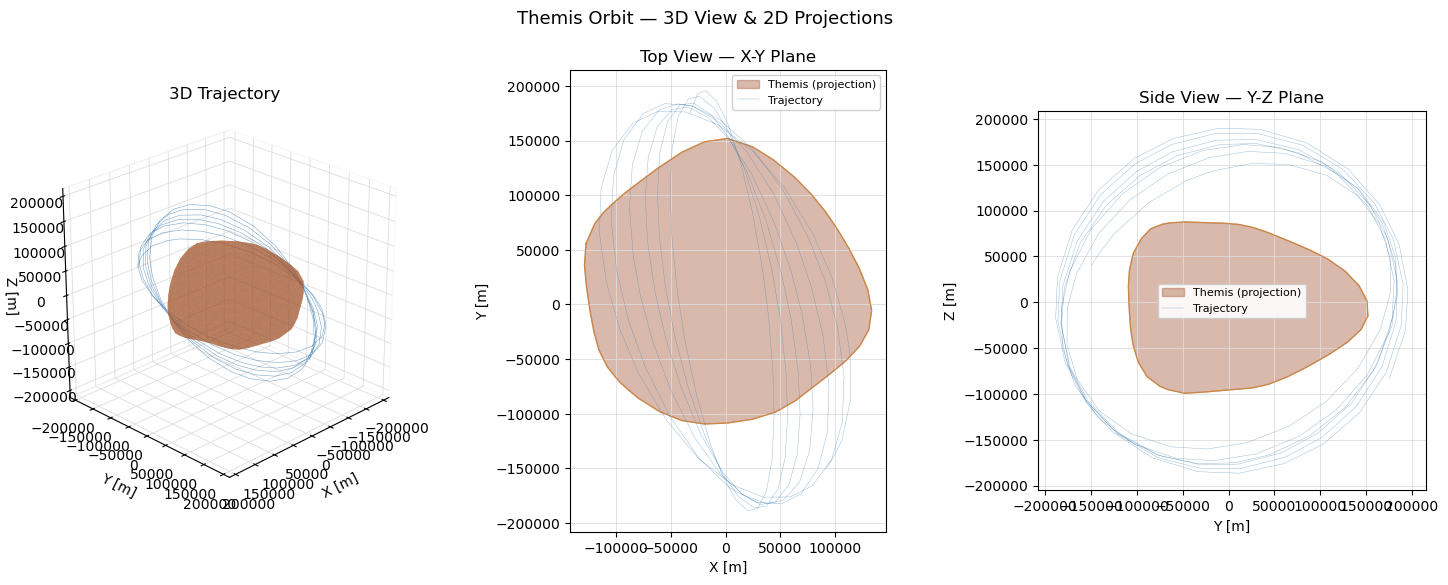

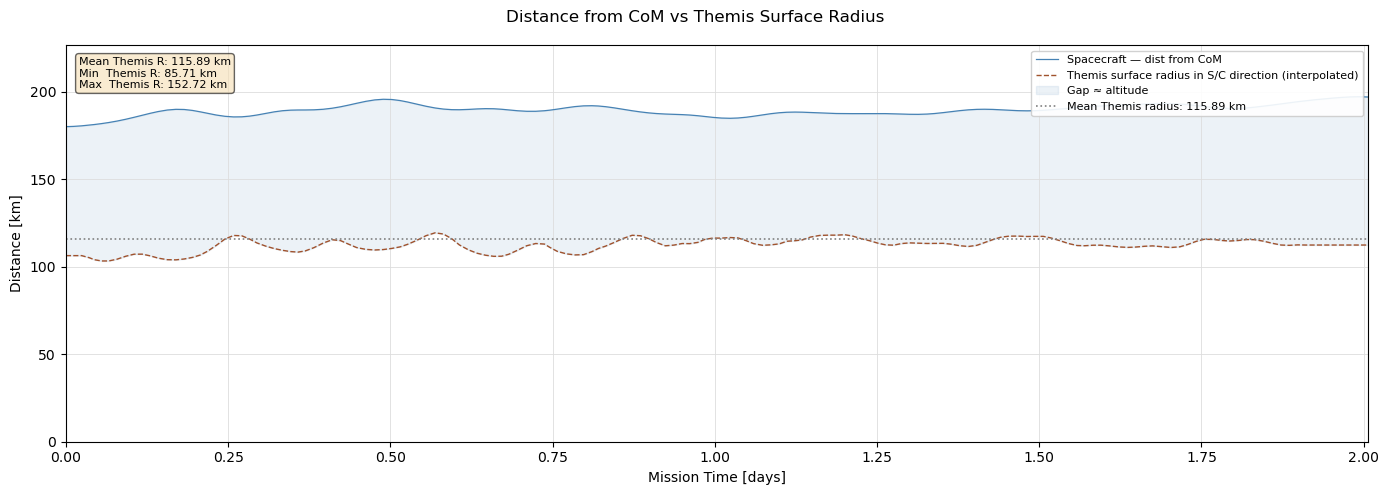

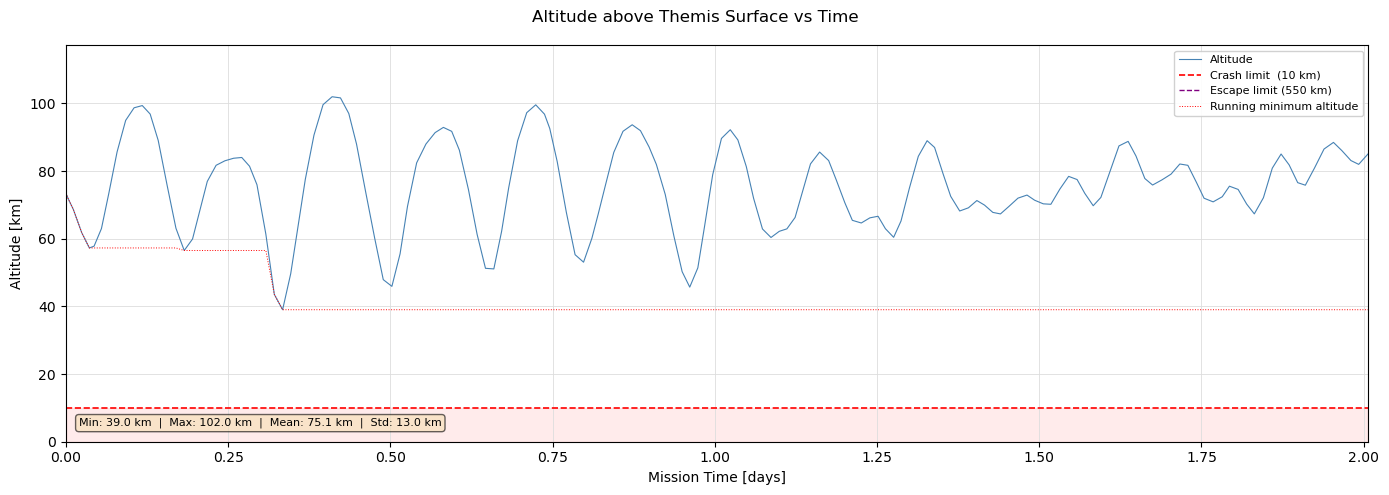

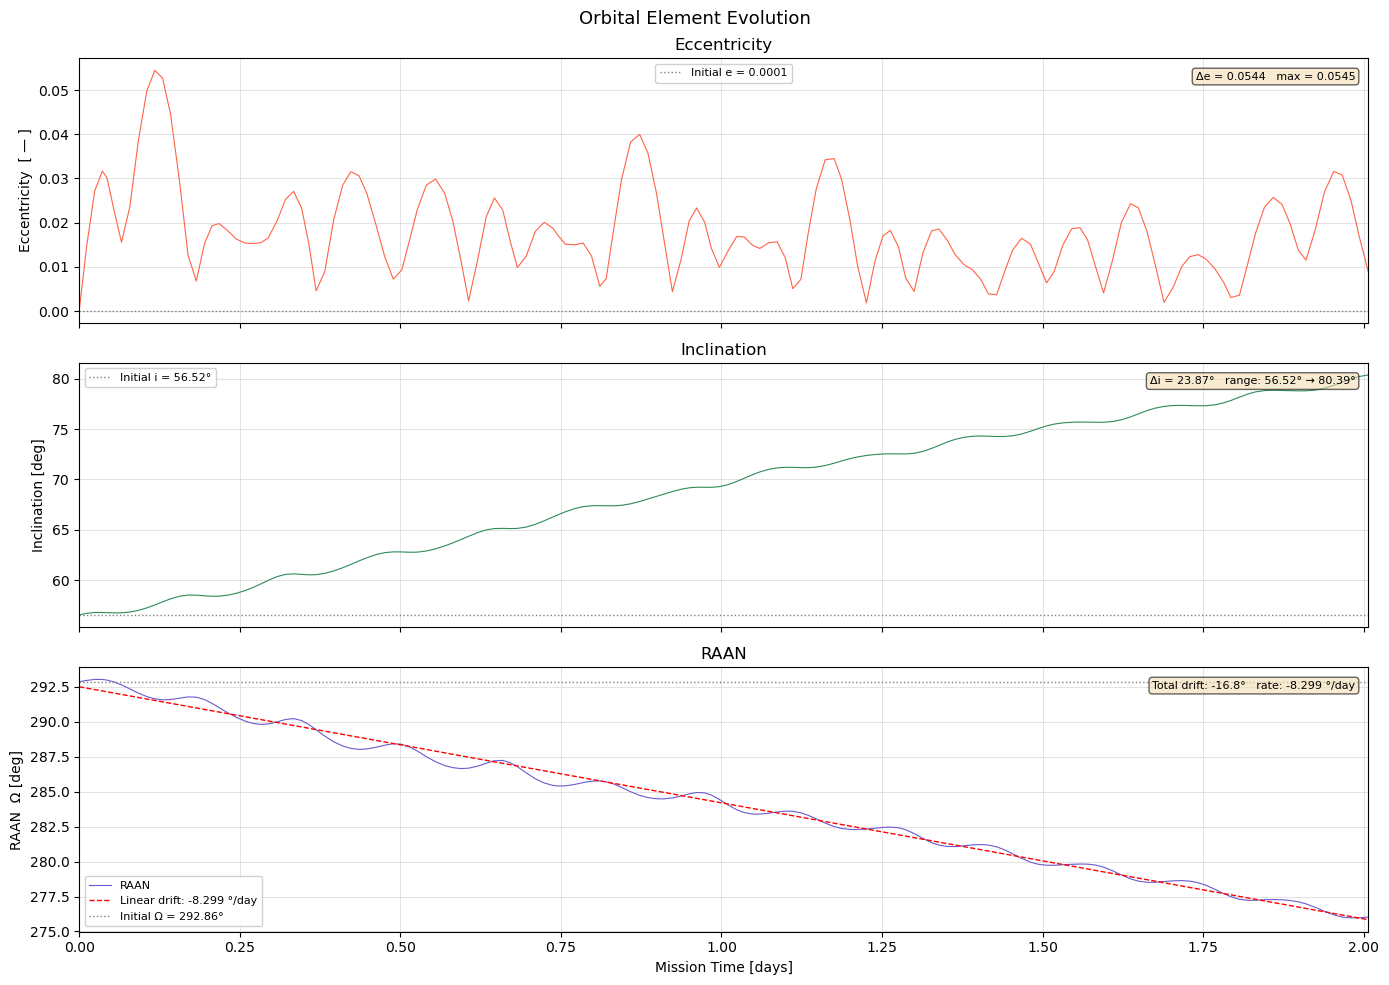


═══════════════════════════════════════════════════════
  MISSION SUMMARY
═══════════════════════════════════════════════════════
  Duration            : 2.01 days
  Altitude  — min     : 39.02 km
  Altitude  — max     : 101.98 km
  Altitude  — mean    : 75.09 km
  CoM dist  — min     : 179.99 km
  CoM dist  — max     : 197.05 km
  Themis R  — mean    : 115.893 km
  Themis R  — min     : 85.714 km
  Themis R  — max     : 152.716 km
  Eccentricity change : 0.0001 → 0.0088
  Inclination change  : 56.52° → 80.39°
  RAAN drift          : -16.8° total  (-8.299 °/day)
═══════════════════════════════════════════════════════


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.gridspec import GridSpec
from scipy.spatial import ConvexHull
from scipy.interpolate import griddata

# ══════════════════════════════════════════════════════════════════════════════
# 0. PULL DATA
# ══════════════════════════════════════════════════════════════════════════════
sim             = orbitProblem.get_last_run_dynamics_simulator()
state_history   = sim.propagation_results.state_history
dep_var_history = sim.propagation_results.dependent_variable_history

states_arr  = np.vstack(list(state_history.values()))
times_state = np.array(list(state_history.keys()))
x = states_arr[:, 0]
y = states_arr[:, 1]
z = states_arr[:, 2]

dep_arr  = np.vstack(list(dep_var_history.values()))
times_dv = np.array(list(dep_var_history.keys()))
days     = (times_dv - times_dv[0]) / 86400.0

# Column map (must match your get_dependent_variables_to_save order)
dist_com_km     = dep_arr[:, 0]  / 1e3    # spherical r = dist from CoM [km]
latitudes_rad   = dep_arr[:, 1]
longitudes_rad  = dep_arr[:, 2]
eccentricity    = dep_arr[:, 4]
inclination_deg = np.rad2deg(dep_arr[:, 5])
raan_deg        = np.rad2deg(dep_arr[:, 7])
altitude_km     = dep_arr[:, 9]  / 1e3    # true altitude above surface [km]

# ══════════════════════════════════════════════════════════════════════════════
# 1. THEMIS SURFACE RADIUS — smooth interpolation + mean radius
# ══════════════════════════════════════════════════════════════════════════════
# Compute radius, lat, lon of every vertex
vx = themis_vertices[:, 0]
vy = themis_vertices[:, 1]
vz = themis_vertices[:, 2]
r_v   = np.sqrt(vx**2 + vy**2 + vz**2)
lat_v = np.arcsin(np.clip(vz / r_v, -1, 1))
lon_v = np.arctan2(vy, vx)

# Mean radius — useful reference value
mean_themis_radius_m  = r_v.mean()
mean_themis_radius_km = mean_themis_radius_m / 1e3
min_themis_radius_km  = r_v.min()  / 1e3
max_themis_radius_km  = r_v.max()  / 1e3

print(f"Themis radius — mean : {mean_themis_radius_km:.3f} km")
print(f"Themis radius — min  : {min_themis_radius_km:.3f} km")
print(f"Themis radius — max  : {max_themis_radius_km:.3f} km")

# Smooth interpolation using scipy griddata (much better than nearest vertex)
# Build a dense lat/lon grid from vertices, interpolate to s/c positions
print("Interpolating surface radius along trajectory...")
surface_radius_km = griddata(
    points = np.column_stack([lat_v, lon_v]),   # known points (vertex positions)
    values = r_v / 1e3,                          # known radii [km]
    xi     = np.column_stack([latitudes_rad, longitudes_rad]),  # query points
    method = 'linear',                           # linear across triangles → smooth
    fill_value = mean_themis_radius_km           # fallback for extrapolation gaps
)

# Apply a light moving average to remove any remaining noise
window = 15
kernel = np.ones(window) / window
surface_radius_km_smooth = np.convolve(surface_radius_km, kernel, mode='same')
# Fix edge effects from convolution
surface_radius_km_smooth[:window//2]  = surface_radius_km_smooth[window//2]
surface_radius_km_smooth[-window//2:] = surface_radius_km_smooth[-window//2]
print("Done.")

# ══════════════════════════════════════════════════════════════════════════════
# GLOBAL STYLE — simple, white background
# ══════════════════════════════════════════════════════════════════════════════
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    'black',
    'axes.labelcolor':   'black',
    'axes.grid':         True,
    'grid.color':        '#dddddd',
    'grid.linewidth':    0.6,
    'xtick.color':       'black',
    'ytick.color':       'black',
    'text.color':        'black',
    'legend.framealpha': 0.9,
    'font.size':         10,
})

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — 3D orbit + X-Y and Y-Z projections
# ══════════════════════════════════════════════════════════════════════════════
fig1 = plt.figure(figsize=(18, 6))
fig1.suptitle('Themis Orbit — 3D View & 2D Projections', fontsize=13)
gs1  = GridSpec(1, 3, figure=fig1, wspace=0.3)

# ── 3D ───────────────────────────────────────────────────────────────────────
ax3d = fig1.add_subplot(gs1[0, 0], projection='3d')
ax3d.set_facecolor('white')
ax3d.xaxis.pane.fill = False
ax3d.yaxis.pane.fill = False
ax3d.zaxis.pane.fill = False

# Themis mesh
poly_verts = themis_vertices[themis_faces]
mesh = Poly3DCollection(poly_verts, alpha=0.5,
                         facecolor='sienna', edgecolor='peru', linewidth=0.05)
ax3d.add_collection3d(mesh)

# Trajectory
ax3d.plot(x, y, z, color='steelblue', linewidth=0.4, alpha=0.7)

LIMS = max(np.abs(x).max(), np.abs(y).max(), np.abs(z).max()) * 1.1
ax3d.set_xlim(-LIMS, LIMS);  ax3d.set_xlabel('X [m]')
ax3d.set_ylim(-LIMS, LIMS);  ax3d.set_ylabel('Y [m]')
ax3d.set_zlim(-LIMS, LIMS);  ax3d.set_zlabel('Z [m]')
ax3d.set_box_aspect([1, 1, 1])
ax3d.set_title('3D Trajectory')
ax3d.view_init(elev=25, azim=45)

# ── X-Y projection ────────────────────────────────────────────────────────────
ax_xy = fig1.add_subplot(gs1[0, 1])
# Themis outline (convex hull of XY projection)
pts_xy  = np.column_stack([vx, vy])
hull_xy = ConvexHull(pts_xy)
hull_xy_pts = pts_xy[hull_xy.vertices]
hull_xy_pts = np.vstack([hull_xy_pts, hull_xy_pts[0]])
ax_xy.fill(hull_xy_pts[:, 0], hull_xy_pts[:, 1],
           color='sienna', alpha=0.4, label='Themis (projection)')
ax_xy.plot(hull_xy_pts[:, 0], hull_xy_pts[:, 1], color='peru', linewidth=0.8)
ax_xy.plot(x, y, color='steelblue', linewidth=0.3, alpha=0.6, label='Trajectory')
ax_xy.set_aspect('equal')
ax_xy.set_xlabel('X [m]');  ax_xy.set_ylabel('Y [m]')
ax_xy.set_title('Top View — X-Y Plane')
ax_xy.legend(fontsize=8)

# ── Y-Z projection ────────────────────────────────────────────────────────────
ax_yz = fig1.add_subplot(gs1[0, 2])
pts_yz  = np.column_stack([vy, vz])
hull_yz = ConvexHull(pts_yz)
hull_yz_pts = pts_yz[hull_yz.vertices]
hull_yz_pts = np.vstack([hull_yz_pts, hull_yz_pts[0]])
ax_yz.fill(hull_yz_pts[:, 0], hull_yz_pts[:, 1],
           color='sienna', alpha=0.4, label='Themis (projection)')
ax_yz.plot(hull_yz_pts[:, 0], hull_yz_pts[:, 1], color='peru', linewidth=0.8)
ax_yz.plot(y, z, color='steelblue', linewidth=0.3, alpha=0.6, label='Trajectory')
ax_yz.set_aspect('equal')
ax_yz.set_xlabel('Y [m]');  ax_yz.set_ylabel('Z [m]')
ax_yz.set_title('Side View — Y-Z Plane')
ax_yz.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig1_3d_projections.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — CoM distance vs Themis surface radius vs time
# ══════════════════════════════════════════════════════════════════════════════
fig2, ax = plt.subplots(figsize=(14, 5))
fig2.suptitle('Distance from CoM vs Themis Surface Radius', fontsize=12)

ax.plot(days, dist_com_km,          color='steelblue',  linewidth=0.9,
        label='Spacecraft — dist from CoM')
ax.plot(days, surface_radius_km_smooth, color='sienna', linewidth=1.0,
        linestyle='--', label='Themis surface radius in S/C direction (interpolated)')
ax.fill_between(days, surface_radius_km_smooth, dist_com_km,
                color='steelblue', alpha=0.10, label='Gap ≈ altitude')

ax.axhline(mean_themis_radius_km, color='gray', ls=':', lw=1.2,
           label=f'Mean Themis radius: {mean_themis_radius_km:.2f} km')

ax.set_xlabel('Mission Time [days]')
ax.set_ylabel('Distance [km]')
ax.set_xlim(0, days[-1])
ax.set_ylim(0, dist_com_km.max() * 1.15)
ax.legend(fontsize=8, loc='upper right')

# Stats box
txt = (f"Mean Themis R: {mean_themis_radius_km:.2f} km\n"
       f"Min  Themis R: {min_themis_radius_km:.2f} km\n"
       f"Max  Themis R: {max_themis_radius_km:.2f} km")
ax.text(0.01, 0.97, txt, transform=ax.transAxes, fontsize=8,
        va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.tight_layout()
plt.savefig('fig2_dist_vs_surface.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Altitude vs time
# ══════════════════════════════════════════════════════════════════════════════
fig3, ax = plt.subplots(figsize=(14, 5))
fig3.suptitle('Altitude above Themis Surface vs Time', fontsize=12)

ax.plot(days, altitude_km, color='steelblue', linewidth=0.8, label='Altitude')

ax.axhline(minimum_altitude / 1e3, color='red',    ls='--', lw=1.2,
           label=f'Crash limit  ({minimum_altitude/1e3:.0f} km)')
ax.axhline(maximum_altitude / 1e3, color='purple', ls='--', lw=1.0,
           label=f'Escape limit ({maximum_altitude/1e3:.0f} km)')

ax.fill_between(days, 0, minimum_altitude/1e3,
                color='red', alpha=0.08)
running_min = np.minimum.accumulate(altitude_km)
ax.plot(days, running_min, color='red', linewidth=0.7,
        linestyle=':', label='Running minimum altitude')

ax.set_xlabel('Mission Time [days]')
ax.set_ylabel('Altitude [km]')
ax.set_xlim(0, days[-1])
ax.set_ylim(0, altitude_km.max() * 1.15)
ax.legend(fontsize=8, loc='upper right')

txt = (f"Min: {altitude_km.min():.1f} km  |  "
       f"Max: {altitude_km.max():.1f} km  |  "
       f"Mean: {altitude_km.mean():.1f} km  |  "
       f"Std: {altitude_km.std():.1f} km")
ax.text(0.01, 0.04, txt, transform=ax.transAxes, fontsize=8,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.tight_layout()
plt.savefig('fig3_altitude_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — e, i, RAAN vs time
# ══════════════════════════════════════════════════════════════════════════════
fig4, axes4 = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig4.suptitle('Orbital Element Evolution', fontsize=13)

# Eccentricity
axes4[0].plot(days, eccentricity, color='tomato', linewidth=0.8)
axes4[0].axhline(eccentricity[0], color='gray', ls=':', lw=1.0,
                  label=f'Initial e = {eccentricity[0]:.4f}')
axes4[0].set_ylabel('Eccentricity  [ — ]')
axes4[0].set_title('Eccentricity')
axes4[0].legend(fontsize=8)
axes4[0].text(0.99, 0.95,
              f'Δe = {eccentricity.max()-eccentricity.min():.4f}   '
              f'max = {eccentricity.max():.4f}',
              transform=axes4[0].transAxes, ha='right', va='top', fontsize=8,
              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# Inclination
axes4[1].plot(days, inclination_deg, color='seagreen', linewidth=0.8)
axes4[1].axhline(inclination_deg[0], color='gray', ls=':', lw=1.0,
                  label=f'Initial i = {inclination_deg[0]:.2f}°')
axes4[1].set_ylabel('Inclination [deg]')
axes4[1].set_title('Inclination')
axes4[1].legend(fontsize=8)
axes4[1].text(0.99, 0.95,
              f'Δi = {inclination_deg.max()-inclination_deg.min():.2f}°   '
              f'range: {inclination_deg.min():.2f}° → {inclination_deg.max():.2f}°',
              transform=axes4[1].transAxes, ha='right', va='top', fontsize=8,
              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# RAAN
coeffs   = np.polyfit(days, raan_deg, 1)
raan_fit = np.polyval(coeffs, days)
axes4[2].plot(days, raan_deg,  color='slateblue', linewidth=0.8, label='RAAN')
axes4[2].plot(days, raan_fit,  color='red',       linewidth=1.0, ls='--',
              label=f'Linear drift: {coeffs[0]:.3f} °/day')
axes4[2].axhline(raan_deg[0], color='gray', ls=':', lw=1.0,
                  label=f'Initial Ω = {raan_deg[0]:.2f}°')
axes4[2].set_ylabel('RAAN  Ω [deg]')
axes4[2].set_xlabel('Mission Time [days]')
axes4[2].set_title('RAAN')
axes4[2].legend(fontsize=8)
axes4[2].text(0.99, 0.95,
              f'Total drift: {raan_deg[-1]-raan_deg[0]:.1f}°   '
              f'rate: {coeffs[0]:.3f} °/day',
              transform=axes4[2].transAxes, ha='right', va='top', fontsize=8,
              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

for ax in axes4:
    ax.set_xlim(0, days[-1])

plt.tight_layout()
plt.savefig('fig4_orbital_elements.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*55)
print("  MISSION SUMMARY")
print("═"*55)
print(f"  Duration            : {days[-1]:.2f} days")
print(f"  Altitude  — min     : {altitude_km.min():.2f} km")
print(f"  Altitude  — max     : {altitude_km.max():.2f} km")
print(f"  Altitude  — mean    : {altitude_km.mean():.2f} km")
print(f"  CoM dist  — min     : {dist_com_km.min():.2f} km")
print(f"  CoM dist  — max     : {dist_com_km.max():.2f} km")
print(f"  Themis R  — mean    : {mean_themis_radius_km:.3f} km")
print(f"  Themis R  — min     : {min_themis_radius_km:.3f} km")
print(f"  Themis R  — max     : {max_themis_radius_km:.3f} km")
print(f"  Eccentricity change : {eccentricity[0]:.4f} → {eccentricity[-1]:.4f}")
print(f"  Inclination change  : {inclination_deg[0]:.2f}° → {inclination_deg[-1]:.2f}°")
print(f"  RAAN drift          : {raan_deg[-1]-raan_deg[0]:.1f}° total  "
      f"({coeffs[0]:.3f} °/day)")
print("═"*55)

Trajectory points used: 163 / 163
Computing coverage grid … (may take ~30 s for 7800 steps × 2592 cells)
Done.
Computing revisit intervals …
Done.


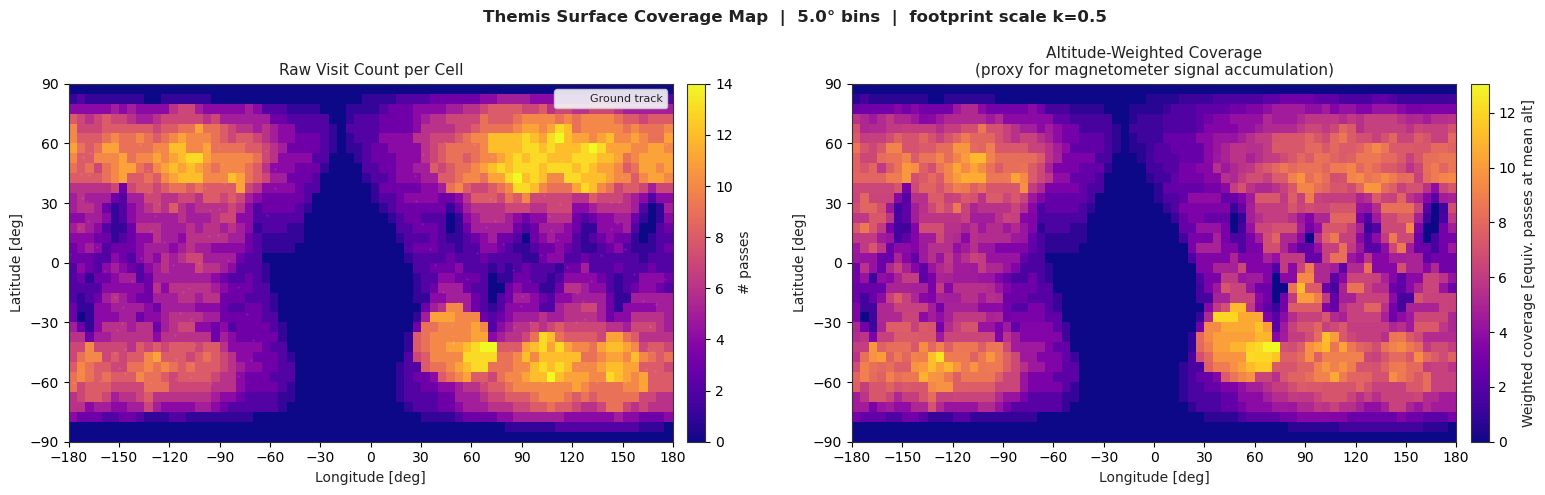

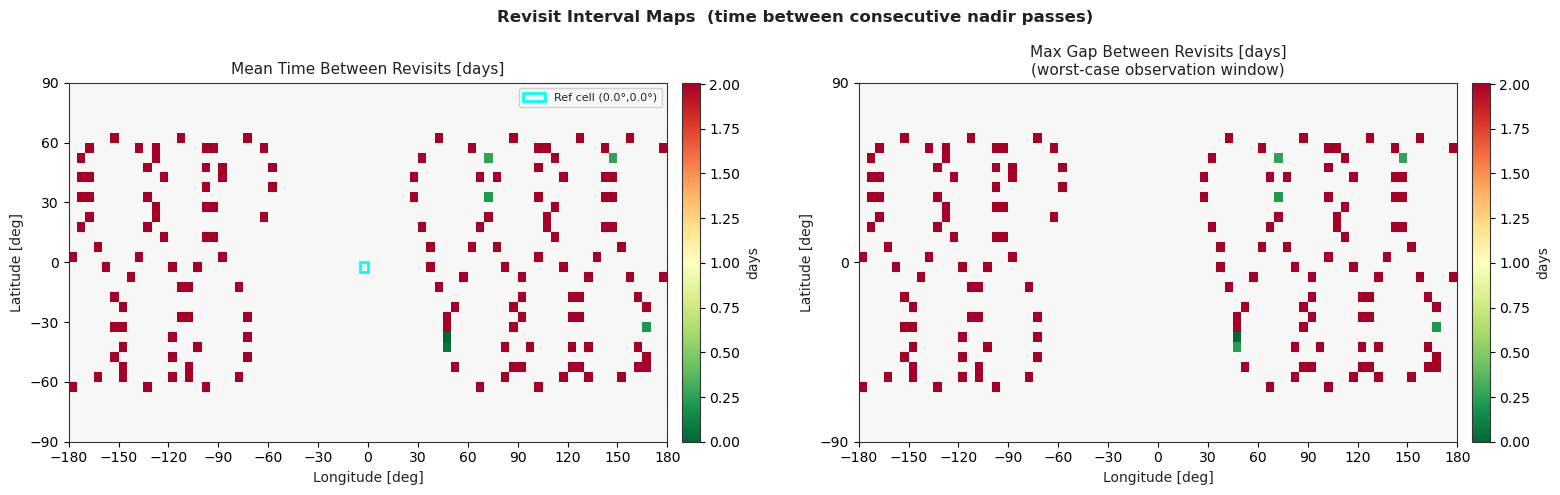

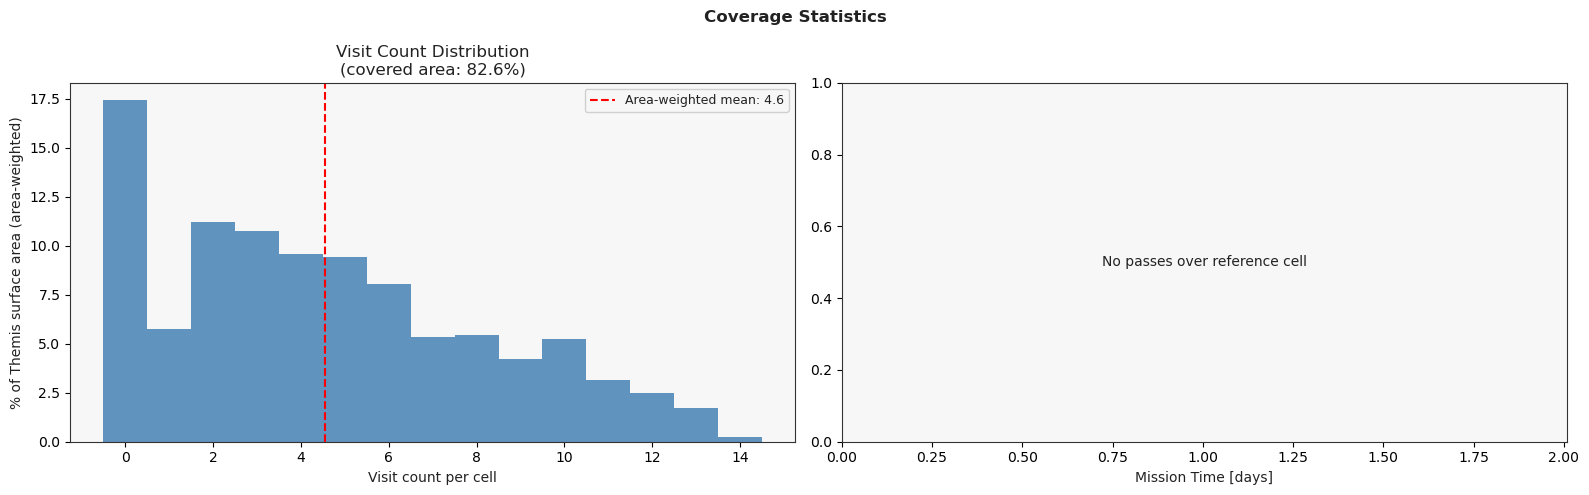


───────────────────────────────────────────────────────
  COVERAGE SUMMARY
───────────────────────────────────────────────────────
  Grid resolution      : 5.0° × 5.0°
  Cell area at equator : 10.1 km × 10.1 km
  Total cells          : 2592
  Cells visited (≥1)   : 2021  (78.0%)
  Area-weighted coverage: 82.6%
  Mean visit count     : 5.7 passes
  Max visit count      : 14 passes
  Mean revisit gap     : 1.936 days  (46.5 h)
  Worst revisit gap    : 2.01 days
  Ref cell (0.0°,0.0°):
    Passes             : 0
───────────────────────────────────────────────────────



In [17]:
"""
Themis Magnetometer Coverage & Revisit Frequency Analysis
==========================================================
Paste this block into your Jupyter notebook after the existing Cell [16].
Requires: dep_arr, latitudes_rad, longitudes_rad, altitude_km, days,
          themis_vertices, minimum_altitude, maximum_altitude
          (all defined in Cell [16])

PRACTICAL NOTES FOR THE AVIONICS TEAM
--------------------------------------
1. Cell-size choice:
   - Themis mean radius ~115.9 km → circumference ~728 km
   - Mean orbital altitude ~76 km
   - Magnetometer resolution (rule of thumb: ~2 × altitude for dipole anomalies)
     ≈ 150 km — almost the diameter of Themis!
   - Conclusion: 2 km × 2 km bins are far finer than the instrument can resolve
     at these altitudes.  5° × 5° bins (~10 km) are recommended, and even those
     are optimistic; 10°–15° (~20–30 km) is physically more defensible.

2. Footprint model used here:
   - Simple altitude-scaled angular footprint: half-angle = arctan(k · h / R_Themis)
     where h = altitude and k = footprint_scale_factor (default 0.5).
   - This means at 76 km altitude the footprint radius on the surface is ~38 km
     or roughly ±19° (varies with altitude).

3. Better approaches for a real magnetometer study:
   a) Altitude-weighted revisit count:  weight each visit by 1/h² so low passes
      count more, high passes count less.
   b) Restrict analysis to a narrower altitude band (e.g. 40–90 km) and use
      that sub-set of the trajectory.
   c) Use a proper 3-D field inversion kernel (Backus-Gilbert or equivalent) to
      compute the true sensitivity distribution on the surface.
   d) For body rotation: the body-fixed lat/lon (dep_arr[:,1:3]) already accounts
      for Themis rotation — no extra correction needed.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from scipy.ndimage import uniform_filter

# ─────────────────────────────────────────────────────────────────────────────
# 0. PARAMETERS  (tweak these)
# ─────────────────────────────────────────────────────────────────────────────
BIN_DEG          = 5.0           # grid cell size in degrees (lat & lon)
FOOTPRINT_SCALE  = 0.5           # footprint half-radius = scale × altitude [km]
                                  # on the surface (0.5 → 38 km at 76 km alt)
ALTITUDE_WEIGHT  = True          # if True: weight by 1/h² (signal strength proxy)
ALT_FILTER_LOW   = None          # set e.g. 40.0 to only count passes below 40 km
ALT_FILTER_HIGH  = None          # set e.g. 100.0 to ignore passes above 100 km
REVISIT_CELL_LAT = 0.0           # reference cell centre latitude  [deg]
REVISIT_CELL_LON = 0.0           # reference cell centre longitude [deg]
R_THEMIS_KM      = 115.893       # mean radius [km] — from your mesh

# ─────────────────────────────────────────────────────────────────────────────
# 1. BUILD LAT / LON GRID
# ─────────────────────────────────────────────────────────────────────────────
lat_edges = np.arange(-90,  90 + BIN_DEG, BIN_DEG)   # (n_lat+1,)
lon_edges = np.arange(-180, 180 + BIN_DEG, BIN_DEG)  # (n_lon+1,)
lat_centres = 0.5 * (lat_edges[:-1] + lat_edges[1:])  # (n_lat,)
lon_centres = 0.5 * (lon_edges[:-1] + lon_edges[1:])  # (n_lon,)
n_lat, n_lon = len(lat_centres), len(lon_centres)

LON_GRID, LAT_GRID = np.meshgrid(lon_centres, lat_centres)   # (n_lat, n_lon)

# Convert grid to radians for great-circle distance
lat_grid_r = np.deg2rad(LAT_GRID)   # (n_lat, n_lon)
lon_grid_r = np.deg2rad(LON_GRID)

# ─────────────────────────────────────────────────────────────────────────────
# 2. TRAJECTORY DATA — apply altitude filter if requested
# ─────────────────────────────────────────────────────────────────────────────
sc_lat_deg = np.rad2deg(latitudes_rad)    # sub-spacecraft latitude  [deg]
sc_lon_deg = np.rad2deg(longitudes_rad)   # sub-spacecraft longitude [deg]
sc_lat_r   = latitudes_rad
sc_lon_r   = longitudes_rad

mask = np.ones(len(altitude_km), dtype=bool)
if ALT_FILTER_LOW  is not None:  mask &= (altitude_km >= ALT_FILTER_LOW)
if ALT_FILTER_HIGH is not None:  mask &= (altitude_km <= ALT_FILTER_HIGH)

sc_lat_r_m   = sc_lat_r[mask]
sc_lon_r_m   = sc_lon_r[mask]
altitude_m   = altitude_km[mask]
days_m       = days[mask]

print(f"Trajectory points used: {mask.sum()} / {len(mask)}")

# ─────────────────────────────────────────────────────────────────────────────
# 3. ACCUMULATE COVERAGE GRID
# ─────────────────────────────────────────────────────────────────────────────
# For each timestep: find all grid cells within the footprint radius and
# increment their counter (optionally weighted by 1/h²).

visit_count    = np.zeros((n_lat, n_lon), dtype=float)
weighted_count = np.zeros((n_lat, n_lon), dtype=float)

# Footprint half-angle on the surface [rad]
# = arcsin( footprint_km / R_Themis_km )  capped at 90°
footprint_km   = FOOTPRINT_SCALE * altitude_m          # (T,)
footprint_angle = np.arcsin(np.clip(footprint_km / R_THEMIS_KM, 0, 1))  # (T,)

print("Computing coverage grid … (may take ~30 s for 7800 steps × 2592 cells)")

for t in range(len(sc_lat_r_m)):
    slat = sc_lat_r_m[t]
    slon = sc_lon_r_m[t]
    fa   = footprint_angle[t]     # angular footprint radius [rad]
    w    = 1.0 / altitude_m[t]**2 if ALTITUDE_WEIGHT else 1.0

    # Great-circle distance from sub-spacecraft point to every grid cell
    # Haversine formula — vectorised over the grid
    dlat = lat_grid_r - slat
    dlon = lon_grid_r - slon
    a = np.sin(dlat / 2)**2 + np.cos(slat) * np.cos(lat_grid_r) * np.sin(dlon / 2)**2
    gc_dist = 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))   # (n_lat, n_lon)

    in_footprint = gc_dist <= fa
    visit_count[in_footprint]    += 1.0
    weighted_count[in_footprint] += w

# Normalise weighted count so units are interpretable
# (relative to a visit at the mean altitude)
if ALTITUDE_WEIGHT:
    weighted_count_norm = weighted_count / (1.0 / np.mean(altitude_m)**2)
else:
    weighted_count_norm = weighted_count.copy()

print("Done.")

# ─────────────────────────────────────────────────────────────────────────────
# 4. REVISIT-INTERVAL MAP  (time between consecutive visits to each cell)
# ─────────────────────────────────────────────────────────────────────────────
# For every cell record the times at which the s/c sub-point was inside it,
# then compute mean gap between successive visits.

print("Computing revisit intervals …")

# Bin sub-spacecraft points directly
lat_idx = np.clip(np.searchsorted(lat_edges[1:], np.rad2deg(sc_lat_r_m)), 0, n_lat - 1)
lon_idx = np.clip(np.searchsorted(lon_edges[1:], np.rad2deg(sc_lon_r_m)), 0, n_lon - 1)

mean_gap_days  = np.full((n_lat, n_lon), np.nan)
max_gap_days   = np.full((n_lat, n_lon), np.nan)

# Build a dict: (i_lat, i_lon) → sorted list of visit times
from collections import defaultdict
visit_times = defaultdict(list)
for t in range(len(lat_idx)):
    visit_times[(lat_idx[t], lon_idx[t])].append(days_m[t])

for (i, j), times in visit_times.items():
    if len(times) > 1:
        gaps = np.diff(sorted(times))
        mean_gap_days[i, j] = gaps.mean()
        max_gap_days[i, j]  = gaps.max()
    else:
        mean_gap_days[i, j] = days_m[-1]   # visited only once → gap = mission duration
        max_gap_days[i, j]  = days_m[-1]

print("Done.")

# ─────────────────────────────────────────────────────────────────────────────
# 5. REVISIT-GAP TRACE for a single reference cell (useful for planning obs windows)
# ─────────────────────────────────────────────────────────────────────────────
ref_i = np.argmin(np.abs(lat_centres - REVISIT_CELL_LAT))
ref_j = np.argmin(np.abs(lon_centres - REVISIT_CELL_LON))
ref_times = np.array(sorted(visit_times.get((ref_i, ref_j), [])))
ref_gaps  = np.diff(ref_times) if len(ref_times) > 1 else np.array([])

# ─────────────────────────────────────────────────────────────────────────────
# 6. PLOTTING
# ─────────────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f7f7f7',
    'axes.edgecolor': '#333', 'axes.labelcolor': '#222',
    'axes.grid': False, 'font.size': 10, 'text.color': '#222'
})

# ── Figure A: Visit count map (raw and weighted) ──────────────────────────────
fig_a, axes_a = plt.subplots(1, 2, figsize=(16, 5))
fig_a.suptitle(f'Themis Surface Coverage Map  |  {BIN_DEG}° bins  |  '
               f'footprint scale k={FOOTPRINT_SCALE}', fontsize=12, fontweight='bold')

cmap_hot = plt.cm.plasma

# Raw visit count
ax = axes_a[0]
im0 = ax.pcolormesh(lon_edges, lat_edges, visit_count, cmap=cmap_hot, shading='flat')
ax.set_title('Raw Visit Count per Cell', fontsize=11)
ax.set_xlabel('Longitude [deg]'); ax.set_ylabel('Latitude [deg]')
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xticks(np.arange(-180, 181, 30))
ax.set_yticks(np.arange(-90, 91, 30))
cbar0 = fig_a.colorbar(im0, ax=ax, pad=0.02)
cbar0.set_label('# passes')
# Ground track overlay (subsampled)
step = max(1, len(sc_lat_deg) // 3000)
ax.scatter(sc_lon_deg[::step], sc_lat_deg[::step],
           s=0.05, c='white', alpha=0.3, label='Ground track')
ax.legend(fontsize=8, loc='upper right')

# Altitude-weighted visit count
ax = axes_a[1]
im1 = ax.pcolormesh(lon_edges, lat_edges, weighted_count_norm, cmap=cmap_hot, shading='flat')
ax.set_title('Altitude-Weighted Coverage\n(proxy for magnetometer signal accumulation)', fontsize=11)
ax.set_xlabel('Longitude [deg]'); ax.set_ylabel('Latitude [deg]')
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xticks(np.arange(-180, 181, 30))
ax.set_yticks(np.arange(-90, 91, 30))
cbar1 = fig_a.colorbar(im1, ax=ax, pad=0.02)
cbar1.set_label('Weighted coverage [equiv. passes at mean alt]')

plt.tight_layout()
plt.savefig('figA_coverage_map.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure B: Revisit interval maps ──────────────────────────────────────────
fig_b, axes_b = plt.subplots(1, 2, figsize=(16, 5))
fig_b.suptitle('Revisit Interval Maps  (time between consecutive nadir passes)',
               fontsize=12, fontweight='bold')

# Mean revisit gap
ax = axes_b[0]
gap_plot = np.ma.masked_invalid(mean_gap_days)
im2 = ax.pcolormesh(lon_edges, lat_edges, gap_plot,
                    cmap='RdYlGn_r', shading='flat',
                    vmin=0, vmax=np.nanpercentile(mean_gap_days[~np.isnan(mean_gap_days)], 95))
ax.set_title('Mean Time Between Revisits [days]', fontsize=11)
ax.set_xlabel('Longitude [deg]'); ax.set_ylabel('Latitude [deg]')
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xticks(np.arange(-180, 181, 30))
ax.set_yticks(np.arange(-90, 91, 30))
# Mark reference cell
ax.add_patch(plt.Rectangle(
    (lon_edges[ref_j], lat_edges[ref_i]), BIN_DEG, BIN_DEG,
    fill=False, edgecolor='cyan', linewidth=2, label=f'Ref cell ({REVISIT_CELL_LAT}°,{REVISIT_CELL_LON}°)'
))
ax.legend(fontsize=8)
cbar2 = fig_b.colorbar(im2, ax=ax, pad=0.02)
cbar2.set_label('days')

# Max revisit gap (worst-case blackout)
ax = axes_b[1]
max_gap_plot = np.ma.masked_invalid(max_gap_days)
im3 = ax.pcolormesh(lon_edges, lat_edges, max_gap_plot,
                    cmap='RdYlGn_r', shading='flat',
                    vmin=0, vmax=np.nanpercentile(max_gap_days[~np.isnan(max_gap_days)], 95))
ax.set_title('Max Gap Between Revisits [days]\n(worst-case observation window)', fontsize=11)
ax.set_xlabel('Longitude [deg]'); ax.set_ylabel('Latitude [deg]')
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xticks(np.arange(-180, 181, 30))
ax.set_yticks(np.arange(-90, 91, 90))
cbar3 = fig_b.colorbar(im3, ax=ax, pad=0.02)
cbar3.set_label('days')

plt.tight_layout()
plt.savefig('figB_revisit_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure C: Coverage histogram + reference cell revisit trace ───────────────
fig_c, axes_c = plt.subplots(1, 2, figsize=(16, 5))
fig_c.suptitle('Coverage Statistics', fontsize=12, fontweight='bold')

# Histogram of visit counts (area-weighted by cos(lat))
ax = axes_c[0]
cos_weights = np.cos(np.deg2rad(LAT_GRID)).ravel()
counts_flat  = visit_count.ravel()
covered_frac = np.sum(cos_weights[counts_flat > 0]) / np.sum(cos_weights) * 100

# Build weighted histogram
bins_h = np.arange(0, visit_count.max() + 2, max(1, int(visit_count.max() / 50)))
hist_vals, bin_edges_h = np.histogram(counts_flat, bins=bins_h, weights=cos_weights)
hist_vals = hist_vals / hist_vals.sum() * 100  # percent of surface area

ax.bar(bin_edges_h[:-1], hist_vals, width=np.diff(bin_edges_h),
       color='steelblue', edgecolor='none', alpha=0.85)
ax.set_xlabel('Visit count per cell')
ax.set_ylabel('% of Themis surface area (area-weighted)')
ax.set_title(f'Visit Count Distribution\n(covered area: {covered_frac:.1f}%)')
ax.axvline(np.average(counts_flat, weights=cos_weights), color='red', ls='--',
           label=f'Area-weighted mean: {np.average(counts_flat, weights=cos_weights):.1f}')
ax.legend(fontsize=9)

# Revisit-time trace for reference cell
ax = axes_c[1]
if len(ref_times) > 0:
    ax.step(ref_times, np.arange(1, len(ref_times) + 1), where='post',
            color='steelblue', linewidth=1.5, label='Cumulative visits')
    ax.set_ylabel('Cumulative visit count', color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')

    if len(ref_gaps) > 0:
        ax2 = ax.twinx()
        gap_x = ref_times[:-1] + ref_gaps / 2     # midpoint of each gap
        ax2.bar(gap_x, ref_gaps, width=ref_gaps * 0.6,
                color='tomato', alpha=0.6, label='Gap duration')
        ax2.set_ylabel('Gap between consecutive visits [days]', color='tomato')
        ax2.tick_params(axis='y', labelcolor='tomato')
        ax2.axhline(ref_gaps.mean(), color='darkred', ls='--', lw=1.2,
                    label=f'Mean gap = {ref_gaps.mean():.2f} days')
        ax2.legend(fontsize=8, loc='upper left')
        ax.set_title(f'Reference Cell: lat={lat_centres[ref_i]:.1f}°, '
                     f'lon={lon_centres[ref_j]:.1f}°\n'
                     f'{len(ref_times)} passes  |  mean gap {ref_gaps.mean():.2f} d  '
                     f'|  max gap {ref_gaps.max():.2f} d')
else:
    ax.text(0.5, 0.5, 'No passes over reference cell',
            ha='center', va='center', transform=ax.transAxes)

ax.set_xlabel('Mission Time [days]')
ax.set_xlim(0, days_m[-1] if len(days_m) > 0 else days[-1])

plt.tight_layout()
plt.savefig('figC_coverage_stats.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 7. SUMMARY STATISTICS
# ─────────────────────────────────────────────────────────────────────────────
valid_gaps = mean_gap_days[~np.isnan(mean_gap_days)]
print("\n" + "─"*55)
print("  COVERAGE SUMMARY")
print("─"*55)
print(f"  Grid resolution      : {BIN_DEG}° × {BIN_DEG}°")
print(f"  Cell area at equator : {BIN_DEG * np.pi/180 * R_THEMIS_KM:.1f} km × "
      f"{BIN_DEG * np.pi/180 * R_THEMIS_KM:.1f} km")
print(f"  Total cells          : {n_lat * n_lon}")
print(f"  Cells visited (≥1)   : {(visit_count > 0).sum()}  "
      f"({(visit_count > 0).sum() / (n_lat*n_lon)*100:.1f}%)")
print(f"  Area-weighted coverage: {covered_frac:.1f}%")
print(f"  Mean visit count     : {visit_count[visit_count>0].mean():.1f} passes")
print(f"  Max visit count      : {visit_count.max():.0f} passes")
print(f"  Mean revisit gap     : {valid_gaps.mean():.3f} days  "
      f"({valid_gaps.mean()*24:.1f} h)")
print(f"  Worst revisit gap    : {max_gap_days[~np.isnan(max_gap_days)].max():.2f} days")
print(f"  Ref cell ({REVISIT_CELL_LAT}°,{REVISIT_CELL_LON}°):")
print(f"    Passes             : {len(ref_times)}")
if len(ref_gaps) > 0:
    print(f"    Mean gap           : {ref_gaps.mean():.3f} days  ({ref_gaps.mean()*24:.1f} h)")
    print(f"    Max gap            : {ref_gaps.max():.3f} days  ({ref_gaps.max()*24:.1f} h)")
print("─"*55)
print()


In [18]:
"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  THEMIS ORBIT ANIMATION  ·  v2
  ─────────────────────────────────────────────────────────────────────────
  Layout
    LEFT          3-D orbit with actual Themis polyhedron mesh
    UPPER-RIGHT   Ground track (fading trail) + 5°×5° live coverage grid
                  + moving footprint arc
    LOWER-RIGHT   Altitude above Themis surface  (live time-series)

  Paste this cell into your Jupyter notebook after running Cells 1–16
  (and optionally the coverage-analysis block).

  Required variables already in scope
    orbitProblem          – AsteroidOrbitProblem with last propagation
    themis_vertices       – (402,3) float64  [metres, re-centred]
    themis_faces          – (800,3) int32
    Themis_radius         – float [metres]   e.g. 99 000
    minimum_altitude      – float [metres]
    maximum_altitude      – float [metres]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection
from matplotlib.patches import Polygon as MplPolygon
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401 (registers projection)
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ═══════════════════════════════════════════════════════════════════════════════
# 0.  USER SETTINGS  ← tweak these
# ═══════════════════════════════════════════════════════════════════════════════
N_FRAMES       = 900       # total animation frames  (÷ FPS = video length in s)
TRAIL_3D       = 140       # 3-D orbit trail [frames]
TRAIL_GT       = 65        # ground-track fading trail [frames]
BIN_DEG        = 5.0       # lat/lon cell size  [degrees]
FOOTPRINT_SC   = 0.5       # footprint half-radius = FOOTPRINT_SC × alt_km (on surface)
FPS            = 30        # output frame-rate
BITRATE        = 10_000    # kbps
OUTPUT_PATH    = r"D:\CALTECH_MS_SPACE_ENGINEERING\105c\themis_orbit_v2.mp4"

# ── Colour palette (deep-space theme) ─────────────────────────────────────────
C_BG       = '#05050f'     # figure background
C_PANEL    = '#0a0a1c'     # axes background
C_GRID     = '#1c1c38'     # subtle grid
C_SAT      = '#ffffff'     # satellite dot
C_TRAIL3D  = '#4d88ff'     # 3-D orbit trail (blue)
C_TRAIL_GT = '#00e5ff'     # ground-track trail (cyan)
C_FP_EDGE  = '#ffd700'     # footprint arc (gold)
C_FP_FILL  = '#ffd700'     # footprint fill
C_THEMIS_F = '#7a3b10'     # Themis face colour
C_THEMIS_E = '#b05a20'     # Themis edge colour
C_ALT_LINE = '#00e5ff'     # altitude line
C_CRASH    = '#ff3b3b'     # crash-limit colour
C_ESCAPE   = '#b44bff'     # escape-limit colour
C_TEXT     = '#ccd9ff'     # axis labels / general text
C_ACCENT   = '#00ffa3'     # bright accent (info boxes)

# Coverage colour-map: 0 visits = dark panel, first visit = teal, more = brighter
_cov_colors = [C_PANEL, '#003322', '#00cc88', '#00ffbb', '#aaffee', '#ffffff']
cov_cmap = mcolors.LinearSegmentedColormap.from_list('cov', _cov_colors, N=512)
cov_cmap.set_under(C_PANEL)   # cells with 0 visits keep panel colour

# ═══════════════════════════════════════════════════════════════════════════════
# 1.  PULL DATA FROM LAST PROPAGATION
# ═══════════════════════════════════════════════════════════════════════════════
_sim      = orbitProblem.get_last_run_dynamics_simulator()
_sh       = _sim.propagation_results.state_history
_dh       = _sim.propagation_results.dependent_variable_history

_times_s  = np.array(list(_sh.keys()))
_states   = np.vstack(list(_sh.values()))
_times_d  = np.array(list(_dh.keys()))
_dep      = np.vstack(list(_dh.values()))

# Align arrays to the shorter of the two (should be identical, but guard)
_N_raw = min(len(_times_s), len(_times_d))
_times_s = _times_s[:_N_raw];  _states = _states[:_N_raw]
_times_d = _times_d[:_N_raw];  _dep    = _dep[:_N_raw]

# Inertial Cartesian [m]
_xf = _states[:, 0];  _yf = _states[:, 1];  _zf = _states[:, 2]

# Body-fixed  lat [rad], lon [rad],  altitude [km]
_latf = _dep[:, 1]
_lonf = _dep[:, 2]
_altf = _dep[:, 9] / 1e3       # metres → km
_dayf = (_times_d - _times_d[0]) / 86400.0

# Orbital elements for info overlay
_eccf  = _dep[:, 4]
_incf  = np.rad2deg(_dep[:, 5])

print(f"Total propagation steps : {_N_raw}")
print(f"Mission duration        : {_dayf[-1]:.2f} days")
print(f"Altitude range          : {_altf.min():.1f} – {_altf.max():.1f} km")

# ═══════════════════════════════════════════════════════════════════════════════
# 2.  DOWNSAMPLE TO N_FRAMES
# ═══════════════════════════════════════════════════════════════════════════════
_step = max(1, _N_raw // N_FRAMES)
_idx  = np.arange(0, _N_raw, _step)
N     = len(_idx)

xa  = _xf[_idx];  ya  = _yf[_idx];  za  = _zf[_idx]
la  = _latf[_idx];  loa = _lonf[_idx]
aa  = _altf[_idx];  da  = _dayf[_idx]
ea  = _eccf[_idx];  ia  = _incf[_idx]
la_deg  = np.rad2deg(la)
loa_deg = np.rad2deg(loa)

# Estimated orbital period from mean motion (for "orbits completed" counter)
_mu_themis = 3.8e8   # m^3/s^2  (same as in gravity field)
_a0_m = _dep[0, 3]  if _dep.shape[1] > 3 else 180_000.0   # initial SMA [m]
_T_orb_days = 2*np.pi * np.sqrt(_a0_m**3 / _mu_themis) / 86400.0

print(f"Animation frames        : {N}  (step={_step})")
print(f"Estimated orbital period: {_T_orb_days*24:.2f} h")

# ═══════════════════════════════════════════════════════════════════════════════
# 3.  PRE-COMPUTE COVERAGE GRID  (cumulative at every animation frame)
# ═══════════════════════════════════════════════════════════════════════════════
lat_edges = np.arange(-90,   90  + BIN_DEG, BIN_DEG)
lon_edges = np.arange(-180,  180 + BIN_DEG, BIN_DEG)
n_lat     = len(lat_edges) - 1     # 36
n_lon     = len(lon_edges) - 1     # 72
lat_c     = 0.5*(lat_edges[:-1] + lat_edges[1:])
lon_c     = 0.5*(lon_edges[:-1] + lon_edges[1:])

# Grid of cell-centre lat/lon [rad], shape (n_lat, n_lon)
_LC, _LOC = np.meshgrid(np.deg2rad(lat_c), np.deg2rad(lon_c), indexing='ij')

R_km        = Themis_radius / 1e3                                  # ~99 km
_fp_ang_rad = np.arcsin(np.clip(FOOTPRINT_SC * aa / R_km, 0, 0.99))  # per frame

print("Pre-computing coverage grids … ", end='', flush=True)
_cov_run    = np.zeros((n_lat, n_lon), dtype=np.float32)
cov_frames  = np.empty((N, n_lat, n_lon), dtype=np.float32)  # ~9 MB for N=900

for _f in range(N):
    _slat = la[_f];  _slon = loa[_f];  _fp = _fp_ang_rad[_f]
    _dlat = _LC - _slat;  _dlon = _LOC - _slon
    _a    = (np.sin(_dlat/2)**2
             + np.cos(_slat) * np.cos(_LC) * np.sin(_dlon/2)**2)
    _gc   = 2*np.arcsin(np.sqrt(np.clip(_a, 0, 1)))
    _cov_run[_gc <= _fp] += 1
    cov_frames[_f] = _cov_run

_cov_max_global = float(cov_frames[-1].max())
_cells_total    = n_lat * n_lon
_cells_covered  = int((cov_frames[-1] > 0).sum())
print(f"done.  {_cells_covered}/{_cells_total} cells covered "
      f"({100*_cells_covered/_cells_total:.1f}%)")

# ═══════════════════════════════════════════════════════════════════════════════
# 4.  PRE-COMPUTE FOOTPRINT ARC  (spherical-cap boundary → lat/lon)
# ═══════════════════════════════════════════════════════════════════════════════
_N_FP = 90   # points around the closed arc

def _footprint_arc(lat0, lon0, alpha, n=_N_FP):
    """
    Spherical-cap boundary of angular radius alpha centred at (lat0, lon0).
    Returns (lon_deg, lat_deg) arrays of length n+1 (closed polygon).
    Uses the standard 'offset position' formula for great-circle arcs.
    """
    phi    = np.linspace(0, 2*np.pi, n + 1)
    ca, sa = np.cos(alpha), np.sin(alpha)
    lat_fp = np.arcsin(np.clip(
        np.sin(lat0)*ca + np.cos(lat0)*sa*np.cos(phi), -1, 1))
    lon_fp = lon0 + np.arctan2(
        np.sin(phi)*sa*np.cos(lat0),
        ca - np.sin(lat0)*np.sin(lat_fp))
    return np.rad2deg(lon_fp), np.rad2deg(lat_fp)   # (lon, lat) for Polygon xy

print("Pre-computing footprint arcs … ", end='', flush=True)
_fp_xy = []    # list of (lon_arr, lat_arr) per frame
for _f in range(N):
    _fp_xy.append(_footprint_arc(la[_f], loa[_f], _fp_ang_rad[_f]))
print("done.")

# ═══════════════════════════════════════════════════════════════════════════════
# 5.  FIGURE LAYOUT
# ═══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(19, 9), facecolor=C_BG)
fig.suptitle(
    'Spacecraft Orbiting  25143 Themis  ·  SH 10×10 Gravity  ·  Polyhedral Shape Model',
    color=C_TEXT, fontsize=12, fontweight='bold', y=0.988,
    fontfamily='monospace')

gs = GridSpec(
    2, 2, figure=fig,
    left=0.03, right=0.975, top=0.955, bottom=0.07,
    wspace=0.28, hspace=0.44,
    width_ratios=[1.3, 1.0])

ax3d  = fig.add_subplot(gs[:, 0], projection='3d')   # full left column
ax_gt = fig.add_subplot(gs[0, 1])                     # upper-right: ground track
ax_alt= fig.add_subplot(gs[1, 1])                     # lower-right: altitude

# ─── 3-D panel ────────────────────────────────────────────────────────────────
ax3d.set_facecolor(C_PANEL)
for pane in [ax3d.xaxis.pane, ax3d.yaxis.pane, ax3d.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor(C_GRID)
ax3d.tick_params(colors=C_GRID, labelsize=6, pad=1)
for _lbl in [ax3d.xaxis.label, ax3d.yaxis.label, ax3d.zaxis.label]:
    _lbl.set_color(C_GRID)
ax3d.set_xlabel('X  [km]', labelpad=0, fontsize=7)
ax3d.set_ylabel('Y  [km]', labelpad=0, fontsize=7)
ax3d.set_zlabel('Z  [km]', labelpad=0, fontsize=7)
ax3d.set_title('3-D Trajectory  (ECLIPJ2000 Inertial Frame)',
               color=C_TEXT, fontsize=9, pad=2)

_LIMS_km = (max(np.abs(xa).max(), np.abs(ya).max(), np.abs(za).max()) * 1.12) / 1e3
ax3d.set_xlim(-_LIMS_km, _LIMS_km)
ax3d.set_ylim(-_LIMS_km, _LIMS_km)
ax3d.set_zlim(-_LIMS_km, _LIMS_km)
ax3d.set_box_aspect([1, 1, 1])

# Actual Themis polyhedron (static — drawn once)
_verts_km   = themis_vertices / 1e3              # metres → km for plotting
_poly_verts = _verts_km[themis_faces]            # (800, 3, 3)
_themis_poly = Poly3DCollection(
    _poly_verts, alpha=0.70,
    facecolor=C_THEMIS_F, edgecolor=C_THEMIS_E, linewidth=0.07, zorder=2)
ax3d.add_collection3d(_themis_poly)

# Ghost of complete orbit (very faint, gives context)
ax3d.plot(_xf/1e3, _yf/1e3, _zf/1e3,
          color='#1a2860', alpha=0.09, linewidth=0.3, zorder=1)

# Live 3-D trail and satellite dot
_trail3d, = ax3d.plot([], [], [], color=C_TRAIL3D, linewidth=1.5,
                       alpha=0.92, zorder=5)
_dot3d,   = ax3d.plot([], [], [], 'o', color=C_SAT, markersize=5.5,
                       markeredgecolor='#88aaff', markeredgewidth=1.3, zorder=10)

# Info text box (3-D panel)
_info3d = ax3d.text2D(
    0.02, 0.975, '', transform=ax3d.transAxes,
    color=C_ACCENT, fontsize=7.5, va='top', fontfamily='monospace',
    bbox=dict(facecolor='#060612', edgecolor='#1a3a2a',
              boxstyle='round,pad=0.38', alpha=0.88))

# ─── Ground-track panel ───────────────────────────────────────────────────────
ax_gt.set_facecolor(C_PANEL)
for _sp in ax_gt.spines.values():
    _sp.set_color(C_GRID)
ax_gt.tick_params(colors=C_TEXT, labelsize=7)
ax_gt.xaxis.label.set_color(C_TEXT)
ax_gt.yaxis.label.set_color(C_TEXT)
ax_gt.set_xlabel('Longitude  [°]', fontsize=8)
ax_gt.set_ylabel('Latitude  [°]',  fontsize=8)
ax_gt.set_title(f'Ground Track & Surface Coverage  ({int(BIN_DEG)}°×{int(BIN_DEG)}° cells)',
                color=C_TEXT, fontsize=9)
ax_gt.set_xlim(-180, 180)
ax_gt.set_ylim(-90, 90)
ax_gt.set_xticks(np.arange(-180, 181, 30))
ax_gt.set_yticks(np.arange(-90,   91, 30))

# Subtle cell-boundary grid
for _ll in lat_edges:
    ax_gt.axhline(_ll, color=C_GRID, lw=0.22, alpha=0.55, zorder=0)
for _ll in lon_edges:
    ax_gt.axvline(_ll, color=C_GRID, lw=0.22, alpha=0.55, zorder=0)

# Continents-style equator / prime-meridian markers
ax_gt.axhline(0,  color=C_GRID, lw=0.6, alpha=0.8, zorder=0)
ax_gt.axvline(0,  color=C_GRID, lw=0.6, alpha=0.8, zorder=0)

# Coverage pcolormesh — starts all dark (clim bottom = 0.5 so 0-visit → under colour)
_cov_init = np.zeros((n_lat, n_lon))
cov_mesh  = ax_gt.pcolormesh(
    lon_edges, lat_edges, _cov_init,
    cmap=cov_cmap, shading='flat',
    vmin=0.5, vmax=max(1.0, _cov_max_global * 0.6),
    zorder=2)

# Colourbar (slim, right side of ground-track panel)
_cbar = fig.colorbar(cov_mesh, ax=ax_gt, fraction=0.03, pad=0.02)
_cbar.set_label('Pass count', color=C_TEXT, fontsize=7)
_cbar.ax.tick_params(colors=C_TEXT, labelsize=6)
_cbar.outline.set_edgecolor(C_GRID)

# Footprint polygon (filled + dashed edge)
_fp_patch = MplPolygon(
    np.zeros((_N_FP + 1, 2)), closed=True,
    facecolor=C_FP_FILL, alpha=0.18,
    edgecolor=C_FP_EDGE, linewidth=1.2,
    linestyle=(0, (5, 3)),             # custom dashes
    zorder=5)
ax_gt.add_patch(_fp_patch)

# Sub-satellite dot (bright white with cyan ring)
_dot_gt, = ax_gt.plot([], [], 'o', color=C_SAT, markersize=7,
                       markeredgecolor=C_TRAIL_GT, markeredgewidth=1.8,
                       zorder=8)

# Fading ground-track trail (LineCollection with alpha gradient)
_gt_lc = LineCollection([], linewidths=1.4, zorder=6)
ax_gt.add_collection(_gt_lc)
# Colour array for trail segments (0=oldest, 1=newest)
_trail_colors = plt.cm.cool(np.linspace(0.3, 1.0, TRAIL_GT))

# Coverage + day stats text
_cov_txt = ax_gt.text(
    0.01, 0.975, '', transform=ax_gt.transAxes,
    color=C_ACCENT, fontsize=7.5, va='top', fontfamily='monospace',
    bbox=dict(facecolor='#060612', edgecolor='#1a3a2a',
              boxstyle='round,pad=0.35', alpha=0.88),
    zorder=10)

# ─── Altitude panel ───────────────────────────────────────────────────────────
ax_alt.set_facecolor(C_PANEL)
for _sp in ax_alt.spines.values():
    _sp.set_color(C_GRID)
ax_alt.tick_params(colors=C_TEXT, labelsize=7)
ax_alt.xaxis.label.set_color(C_TEXT)
ax_alt.yaxis.label.set_color(C_TEXT)
ax_alt.set_xlabel('Mission Time  [days]', fontsize=8)
ax_alt.set_ylabel('Altitude  [km]',       fontsize=8)
ax_alt.set_title('Altitude above Themis Surface', color=C_TEXT, fontsize=9)
ax_alt.set_xlim(0, da[-1])
_alt_ymin = max(0.0, aa.min() * 0.80)
_alt_ymax = aa.max() * 1.14
ax_alt.set_ylim(_alt_ymin, _alt_ymax)
ax_alt.grid(True, color=C_GRID, linewidth=0.35, alpha=0.7)

# Horizontal reference lines
ax_alt.axhline(minimum_altitude / 1e3, color=C_CRASH,  ls='--', lw=1.1, alpha=0.8,
               label=f'Crash limit   {minimum_altitude/1e3:.0f} km')
ax_alt.axhline(maximum_altitude / 1e3, color=C_ESCAPE, ls='--', lw=0.9, alpha=0.7,
               label=f'Escape limit  {maximum_altitude/1e3:.0f} km')
# Danger-zone shading (below crash limit)
ax_alt.axhspan(_alt_ymin, minimum_altitude/1e3,
               color=C_CRASH, alpha=0.07, zorder=0)

# Ghost of full altitude trace (static reference)
ax_alt.plot(da, aa, color='#182840', linewidth=0.5, alpha=0.5, zorder=1)

# Live altitude line and dot
_alt_line, = ax_alt.plot([], [], color=C_ALT_LINE, linewidth=1.3,
                          alpha=0.95, zorder=4)
_alt_dot,  = ax_alt.plot([], [], 'o', color=C_SAT, markersize=5,
                          markeredgecolor=C_ALT_LINE, markeredgewidth=1.3, zorder=5)

# Vertical "now" line on altitude panel
_alt_vline = ax_alt.axvline(0, color='#555577', lw=0.8, ls=':', alpha=0.7, zorder=3)

ax_alt.legend(fontsize=7, loc='upper right',
              facecolor=C_BG, edgecolor=C_GRID, labelcolor=C_TEXT)

# Stats text inside altitude panel
_alt_txt = ax_alt.text(
    0.01, 0.96, '', transform=ax_alt.transAxes,
    color=C_TEXT, fontsize=7.5, va='top', fontfamily='monospace',
    bbox=dict(facecolor='#060612', edgecolor=C_GRID,
              boxstyle='round,pad=0.35', alpha=0.88),
    zorder=6)

# ═══════════════════════════════════════════════════════════════════════════════
# 6.  HELPER — build fading LineCollection for ground track
# ═══════════════════════════════════════════════════════════════════════════════
def _make_trail_lc(lon_arr, lat_arr):
    """
    Returns a list of 2-pt segments and matching RGBA colours
    that fade from transparent (oldest) to bright cyan (newest).
    """
    n = len(lon_arr)
    if n < 2:
        return [], []
    pts   = np.column_stack([lon_arr, lat_arr]).reshape(-1, 1, 2)
    segs  = np.concatenate([pts[:-1], pts[1:]], axis=1)   # (n-1, 2, 2)
    n_seg = len(segs)
    # Alpha: oldest segment → 0.05, newest → 0.95
    alphas = np.linspace(0.05, 0.95, n_seg)
    # Colour: interpolate from deep-blue to bright-cyan
    r = np.interp(alphas, [0, 1], [0.05, 0.00])
    g = np.interp(alphas, [0, 1], [0.55, 0.90])
    b = np.interp(alphas, [0, 1], [0.80, 1.00])
    rgba = np.stack([r, g, b, alphas], axis=1)
    return segs, rgba

# ═══════════════════════════════════════════════════════════════════════════════
# 7.  ANIMATION CAMERA  (slow 360° pan + gentle elevation rise)
# ═══════════════════════════════════════════════════════════════════════════════
_AZIM_START, _AZIM_END = 25, 385        # full 360°
_ELEV_START, _ELEV_END = 20, 32

# ═══════════════════════════════════════════════════════════════════════════════
# 8.  UPDATE FUNCTION
# ═══════════════════════════════════════════════════════════════════════════════
def update(f):
    """Called for each animation frame f ∈ [0, N)."""
    _frac = f / max(N - 1, 1)

    # ── A.  Camera rotation ─────────────────────────────────────────────────
    ax3d.view_init(
        elev = _ELEV_START + _frac * (_ELEV_END - _ELEV_START),
        azim = _AZIM_START + _frac * (_AZIM_END - _AZIM_START))

    # ── B.  3-D trail & satellite dot ───────────────────────────────────────
    _t0 = max(0, f - TRAIL_3D)
    _trail3d.set_data(xa[_t0:f+1]/1e3, ya[_t0:f+1]/1e3)
    _trail3d.set_3d_properties(za[_t0:f+1]/1e3)
    _dot3d.set_data([xa[f]/1e3], [ya[f]/1e3])
    _dot3d.set_3d_properties([za[f]/1e3])

    # ── C.  3-D info text ───────────────────────────────────────────────────
    _n_orbits = da[f] / _T_orb_days
    _info3d.set_text(
        f' Day    {da[f]:6.2f}\n'
        f' Orbit  {_n_orbits:6.1f}\n'
        f' Alt    {aa[f]:6.1f} km\n'
        f' Ecc    {ea[f]:.4f}\n'
        f' Inc    {ia[f]:.2f}°')

    # ── D.  Coverage pcolormesh ─────────────────────────────────────────────
    _cov_now = cov_frames[f]
    cov_mesh.set_array(_cov_now.ravel())
    _local_max = float(_cov_now.max())
    if _local_max > 0.5:
        cov_mesh.set_clim(0.5, max(_local_max * 0.65, 1.0))

    # ── E.  Fading ground-track trail (LineCollection) ──────────────────────
    _g0 = max(0, f - TRAIL_GT)
    _segs, _rgba = _make_trail_lc(loa_deg[_g0:f+1], la_deg[_g0:f+1])
    if len(_segs):
        _gt_lc.set_segments(_segs)
        _gt_lc.set_color(_rgba)
    else:
        _gt_lc.set_segments([])

    # ── F.  Satellite dot on ground track ───────────────────────────────────
    _dot_gt.set_data([loa_deg[f]], [la_deg[f]])

    # ── G.  Footprint polygon ───────────────────────────────────────────────
    _fp_lon, _fp_lat = _fp_xy[f]
    _fp_patch.set_xy(np.column_stack([_fp_lon, _fp_lat]))

    # ── H.  Coverage stats text ─────────────────────────────────────────────
    _pct_now    = float((_cov_now > 0).sum()) / _cells_total * 100.0
    _cells_now  = int((_cov_now > 0).sum())
    _cov_txt.set_text(
        f' Day {da[f]:.1f} / {da[-1]:.1f}\n'
        f' Coverage  {_pct_now:.1f}%\n'
        f' Cells     {_cells_now}/{_cells_total}')

    # ── I.  Altitude live line + dot + vertical cursor ──────────────────────
    _alt_line.set_data(da[:f+1], aa[:f+1])
    _alt_dot.set_data([da[f]], [aa[f]])
    _alt_vline.set_xdata([da[f], da[f]])

    _alt_txt.set_text(
        f' Now   {aa[f]:.1f} km\n'
        f' Min ↓ {aa[:f+1].min():.1f} km\n'
        f' Mean  {aa[:f+1].mean():.1f} km\n'
        f' Max ↑ {aa[:f+1].max():.1f} km')

    return (_trail3d, _dot3d, cov_mesh, _gt_lc, _dot_gt,
            _fp_patch, _alt_line, _alt_dot, _alt_vline,
            _info3d, _cov_txt, _alt_txt)

# ═══════════════════════════════════════════════════════════════════════════════
# 9.  RENDER & SAVE
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\nRendering {N} frames at {FPS} fps  →  {N/FPS:.1f} s video …")
print("(expect ~1–3 min per 100 frames due to 3-D Poly3DCollection redraws)\n")

ani = animation.FuncAnimation(
    fig, update,
    frames=N,
    interval=1000 // FPS,
    blit=False)           # must be False for 3-D camera rotation

writer_mp4 = animation.FFMpegWriter(
    fps=FPS,
    bitrate=BITRATE,
    extra_args=[
        '-vcodec',    'libx264',
        '-pix_fmt',   'yuv420p',
        '-profile:v', 'high',
        '-level',     '4.1',
        '-preset',    'slow',       # better quality at same bitrate
        '-movflags',  '+faststart', # web-friendly streaming
    ])

ani.save(OUTPUT_PATH, writer=writer_mp4, dpi=130,
         savefig_kwargs={'facecolor': C_BG})
plt.close(fig)
print(f"\n✓  Saved  →  {OUTPUT_PATH}")

# ─── Optional GIF (smaller dpi, lower fps) ────────────────────────────────────
# gif_path = OUTPUT_PATH.replace('.mp4', '.gif')
# writer_gif = animation.PillowWriter(fps=20)
# ani.save(gif_path, writer=writer_gif, dpi=90,
#          savefig_kwargs={'facecolor': C_BG})
# print(f"✓  GIF    →  {gif_path}")

Total propagation steps : 163
Mission duration        : 2.01 days
Altitude range          : 39.0 – 102.0 km
Animation frames        : 163  (step=1)
Estimated orbital period: 6.84 h
Pre-computing coverage grids … done.  2228/2592 cells covered (86.0%)
Pre-computing footprint arcs … done.

Rendering 163 frames at 30 fps  →  5.4 s video …
(expect ~1–3 min per 100 frames due to 3-D Poly3DCollection redraws)


✓  Saved  →  D:\CALTECH_MS_SPACE_ENGINEERING\105c\themis_orbit_v2.mp4
